In [1]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import os
import tensorflow as tf

2024-02-06 16:13:25.940723: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-06 16:13:45.111629: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
from keras.models import Model, load_model
from keras.layers import Input,Dense, BatchNormalization #layers of autoencoder
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping #callbacks
from keras import regularizers #regularization
import keras
import sklearn.metrics as metrics #metrics librry

In [3]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

2024-02-06 16:14:32.664529: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:35.791373: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:35.791526: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 17695752725059466649
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 23368368128
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 7825014508095987512
 physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9"
 xla_global_id: 416903419]

s-bus-pci#L344-L355
2024-02-06 16:14:35.856650: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:35.856766: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:35.856871: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /device:GPU:0 with 22285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

# Load Dataset

## Real normal

In [5]:
alpha_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)

## Real Anomalous

In [10]:
alpha_sub_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)

# To compare the similarity using euclidean distance, we need the signal data to be the same lenght. As such, we will remove access information at the end as we assume we have knowledge of the length of time the benign program will take.

In [15]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

# alpha

In [16]:
print(alpha_SNR_30.shape)

(3000, 12)


In [17]:
print(alpha_sub_SNR_25.shape)
print(alpha_sub_SNR_20.shape)
print(alpha_sub_SNR_15.shape)

(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)


In [18]:
alpha_sub_SNR_25 = cutToLength(alpha_sub_SNR_25, 12)
alpha_sub_SNR_20 = cutToLength(alpha_sub_SNR_20, 12)
alpha_sub_SNR_15 = cutToLength(alpha_sub_SNR_15, 12)
print(alpha_SNR_20.shape)
print(alpha_sub_SNR_20.shape)

(3000, 12)
(1312, 12)


# Method to do anomaly detection

In [31]:
def test_autoencoder(program_N, program_A, program, SNR, train_amount, check = 20):
    with tf.device('/device:GPU:0'):
        save_path = "./Results/AE/" + program + "_SNR_" + str(SNR) + "/" + str(train_amount) + "/"
        
        # Check whether the specified path exists or not
        isExist = os.path.exists(save_path)
        if not isExist:
          # Create a new directory because it does not exist 
          os.makedirs(save_path)

        best_Stat = 0

        # Dataset
        train_N = np.copy(program_N[0:train_amount])
        test_N = np.copy(program_N[2000:3000])
        test_A = np.copy(program_A[0:1000])
        # Create the X_train, X_test, and y_test
        X_train = train_N.astype('float32')
        X_test = np.concatenate((test_N, test_A)).astype('float32')

        zeros = np.repeat(0,test_N.shape[0])
        ones = np.repeat(1,test_A.shape[0])
        y_test = np.concatenate((zeros,ones))

        for i in range(check):
            # Semi-supervised AutoEncoder
            from numpy.random import seed
            seed(4)
            input_dim = X_train.shape[1]

            Input_layer=Input(shape=(input_dim,))


            ## Create model
            Input_layer=Input(shape=(input_dim,))
            #encoder
            encoding_dim = 100
            from keras import initializers
            #init = initializers.VarianceScaling(scale=1.0, mode='fan_in', distribution='normal', seed=42)
            #encoder
            encoder=Dense(units=100,activation='tanh', use_bias=False, 
                          activity_regularizer=regularizers.l1(10e-5))(Input_layer)
            encoder=BatchNormalization()(encoder)
            encoder=Dense(units=int(50), activation='relu')(encoder)
            encoder=Dense(units=int(25), activation='relu')(encoder)

            #decoder
            decoder=Dense(units=int(50), activation='relu')(encoder)
            decoder=Dense(units=int(100), activation='relu')(decoder)
            decoder=Dense(units=input_dim,activation='relu')(decoder)

            #model
            autoencoder=Model(inputs=Input_layer,outputs=decoder)
            encodermodel=Model(inputs=Input_layer,outputs=encoder)

            # Settings for training the model
            epochs= 400
            batch_size=128

            #TensorBoard=TensorBoard(log_dir='./logs',histogram_freq=0,write_grads=True,write_images=True)
            best_weights_filepath = save_path + "model_temp.hdf5"

            earlyStopping=EarlyStopping(monitor='val_loss', patience=50, verbose=0, mode='auto')

            saveBestModel = ModelCheckpoint(best_weights_filepath, monitor='val_loss', 
                                            verbose=0, save_best_only=True, mode='auto')

            ## compile and fit the model
            #we use 90% of data for train and 10% for validation
            autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001)
                                ,loss='mean_squared_error',metrics=['accuracy'])

            history=autoencoder.fit(X_train,X_train,
                                epochs=epochs,batch_size=batch_size,shuffle=False,
                                validation_split=0.1,verbose=0, 
                                callbacks=[saveBestModel,earlyStopping]).history
            autoencoder.load_weights(best_weights_filepath)

            # Predict
            predictions_AE=autoencoder.predict(X_test, verbose=0)

            # Find the mean square error
            mse=np.mean(np.power(X_test - predictions_AE, 2), axis=1)

            fpr, tpr, tresholds = metrics.roc_curve(y_test, mse)
            scores_AE=[]
            for treshold in tresholds:
                y_hat_AE = (mse > treshold).astype(int)
                scores_AE.append([metrics.accuracy_score(y_pred=y_hat_AE, y_true=y_test),
                              metrics.f1_score(y_pred=y_hat_AE, y_true=y_test),
                             metrics.recall_score(y_pred=y_hat_AE, y_true=y_test),
                             metrics.precision_score(y_pred=y_hat_AE, y_true=y_test, zero_division=0.0),
                             metrics.fbeta_score(y_pred=y_hat_AE, y_true=y_test, beta=2),
                             metrics.cohen_kappa_score(y1=y_hat_AE, y2=y_test)])

            roc_auc = metrics.auc(fpr, tpr)

            scores_AE = np.array(scores_AE)
            final_tresh = tresholds[scores_AE[:, 0].argmax()]
            y_hat_AE = (mse > final_tresh).astype(int)
            best_score_AE = scores_AE[scores_AE[:, 0].argmax(),:]
            accuracy_score_AE = best_score_AE[0]
            f1_score_AE = best_score_AE[1]
            recall_score_AE = best_score_AE[2]
            precision_score_AE = best_score_AE[3]
            fbeta_score_AE = best_score_AE[4]
            cohen_kappa_score_AE = best_score_AE[5]

            if roc_auc + accuracy_score_AE > best_Stat:
                best_Stat = roc_auc + accuracy_score_AE

                best_model = autoencoder.save_weights(save_path + "best_weigths.hdf5")

            del autoencoder
            keras.backend.clear_session()

        # Show results of best model
        import matplotlib.pyplot as plt

        params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)

        # Semi-supervised AutoEncoder
        from numpy.random import seed
        seed(4)
        input_dim = X_train.shape[1]

        Input_layer=Input(shape=(input_dim,))


        ## Create model
        Input_layer=Input(shape=(input_dim,))
        #encoder
        encoding_dim = 100
        from keras import initializers
        #init = initializers.VarianceScaling(scale=1.0, mode='fan_in', distribution='normal', seed=42)
        #encoder
        encoder=Dense(units=100,activation='tanh', use_bias=False, 
                      activity_regularizer=regularizers.l1(10e-5))(Input_layer)
        encoder=BatchNormalization()(encoder)
        encoder=Dense(units=int(50), activation='relu')(encoder)
        encoder=Dense(units=int(25), activation='relu')(encoder)

        #decoder
        decoder=Dense(units=int(50), activation='relu')(encoder)
        decoder=Dense(units=int(100), activation='relu')(decoder)
        decoder=Dense(units=input_dim,activation='relu')(decoder)

        #model
        autoencoder=Model(inputs=Input_layer,outputs=decoder)
        encodermodel=Model(inputs=Input_layer,outputs=encoder)

        # Settings for training the model
        epochs= 400
        batch_size=128

        autoencoder.load_weights(save_path + "best_weigths.hdf5")

        # Predict
        predictions_AE=autoencoder.predict(X_test, verbose=0)

        # Find the mean square error
        mse=np.mean(np.power(X_test - predictions_AE, 2), axis=1)

        #plotting the history of the model
        plt.figure()
        plt.plot(history['loss'],label='loss')
        plt.legend()
        plt.plot(history['val_loss'],label='validation loss')
        plt.legend()
        plt.title('loss in train and validation split')
        plt.show()

        params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)

        fpr, tpr, tresholds = metrics.roc_curve(y_test, mse)
        scores_AE=[]
        for treshold in tresholds:
            y_hat_AE = (mse > treshold).astype(int)
            scores_AE.append([metrics.accuracy_score(y_pred=y_hat_AE, y_true=y_test),
                              metrics.f1_score(y_pred=y_hat_AE, y_true=y_test),
                             metrics.recall_score(y_pred=y_hat_AE, y_true=y_test),
                             metrics.precision_score(y_pred=y_hat_AE, y_true=y_test, zero_division=0.0),
                             metrics.fbeta_score(y_pred=y_hat_AE, y_true=y_test, beta=2),
                             metrics.cohen_kappa_score(y1=y_hat_AE, y2=y_test)])

        roc_auc = metrics.auc(fpr, tpr)

        # method I: plt
        import matplotlib.pyplot as plt
        plt.title('Receiver Operating Characteristic')
        plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
        plt.legend(loc = 'lower right')
        plt.plot([0, 1], [0, 1],'r--')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

        scores_AE = np.array(scores_AE)
        final_tresh = tresholds[scores_AE[:, 0].argmax()]
        y_hat_AE = (mse > final_tresh).astype(int)
        best_score_AE = scores_AE[scores_AE[:, 0].argmax(),:]
        accuracy_score_AE = best_score_AE[0]
        f1_score_AE = best_score_AE[1]
        recall_score_AE = best_score_AE[2]
        precision_score_AE = best_score_AE[3]
        fbeta_score_AE = best_score_AE[4]
        cohen_kappa_score_AE = best_score_AE[5]

        params = {'legend.fontsize': 30,
                  'figure.figsize': (15, 15),
                 'axes.labelsize': 40,
                 'axes.titlesize':30,
                 'xtick.labelsize':30,
                 'ytick.labelsize':30,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)



        print('The accuracy score is": %.3f' % accuracy_score_AE)
        print('The f1 score is": %.3f' % f1_score_AE)
        print('The recall score is": %.3f' % recall_score_AE)
        print('The precision score is": %.3f' % precision_score_AE)
        print('The f2 score is": %.3f' % fbeta_score_AE)
        print('The Kappa score is": %.3f' % cohen_kappa_score_AE)
        target_names = ['class 0 (Normal)', 'class 1 (Fraud)']
        print(classification_report(y_test, y_hat_AE, target_names=target_names))

        cm = pd.crosstab(y_test, y_hat_AE, rownames=['Actual'], colnames=['Predicted'])
        fig, (ax1) = plt.subplots(ncols=1, figsize=(15,15))
        sns.heatmap(cm, 
                    xticklabels=['Benign', 'Anomalous'],
                    yticklabels=['Benign', 'Anomalous'],
                    annot=True,ax=ax1,
                    linewidths=.2,linecolor="Darkblue", cmap="Blues", fmt='d', annot_kws={"fontsize":25})
        plt.title('', fontsize=100)
        plt.savefig(save_path + "CM_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

        del autoencoder
        keras.backend.clear_session()

# Alpha

# Settings

In [32]:
program = "alpha"

SNR = "15"

program_N = np.copy(alpha_SNR_15)
program_A = np.copy(alpha_sub_SNR_15)

# train_amount = 2000

2024-02-06 16:14:44.557164: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:44.557380: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-06 16:14:44.557492: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

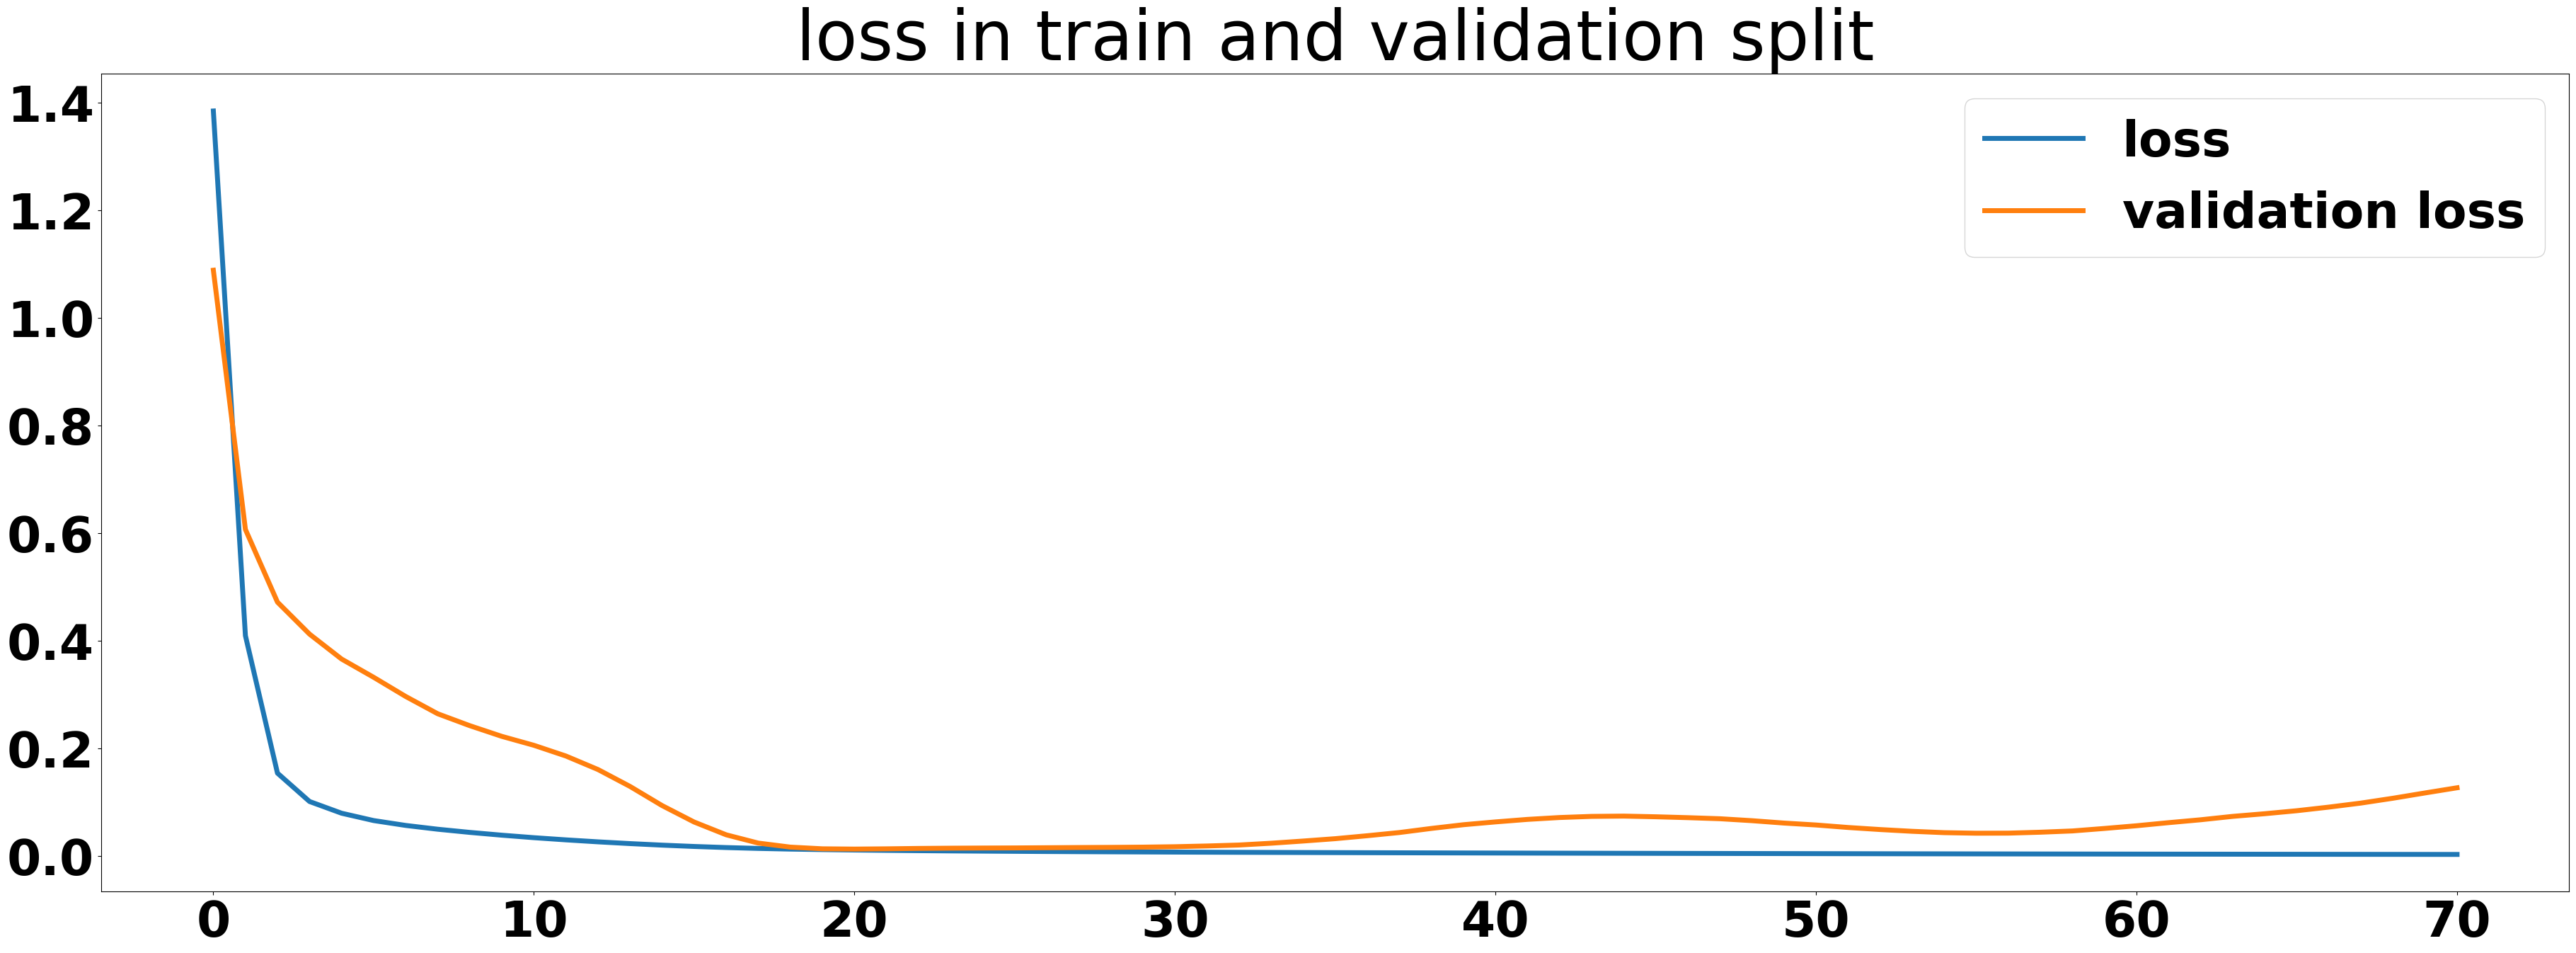

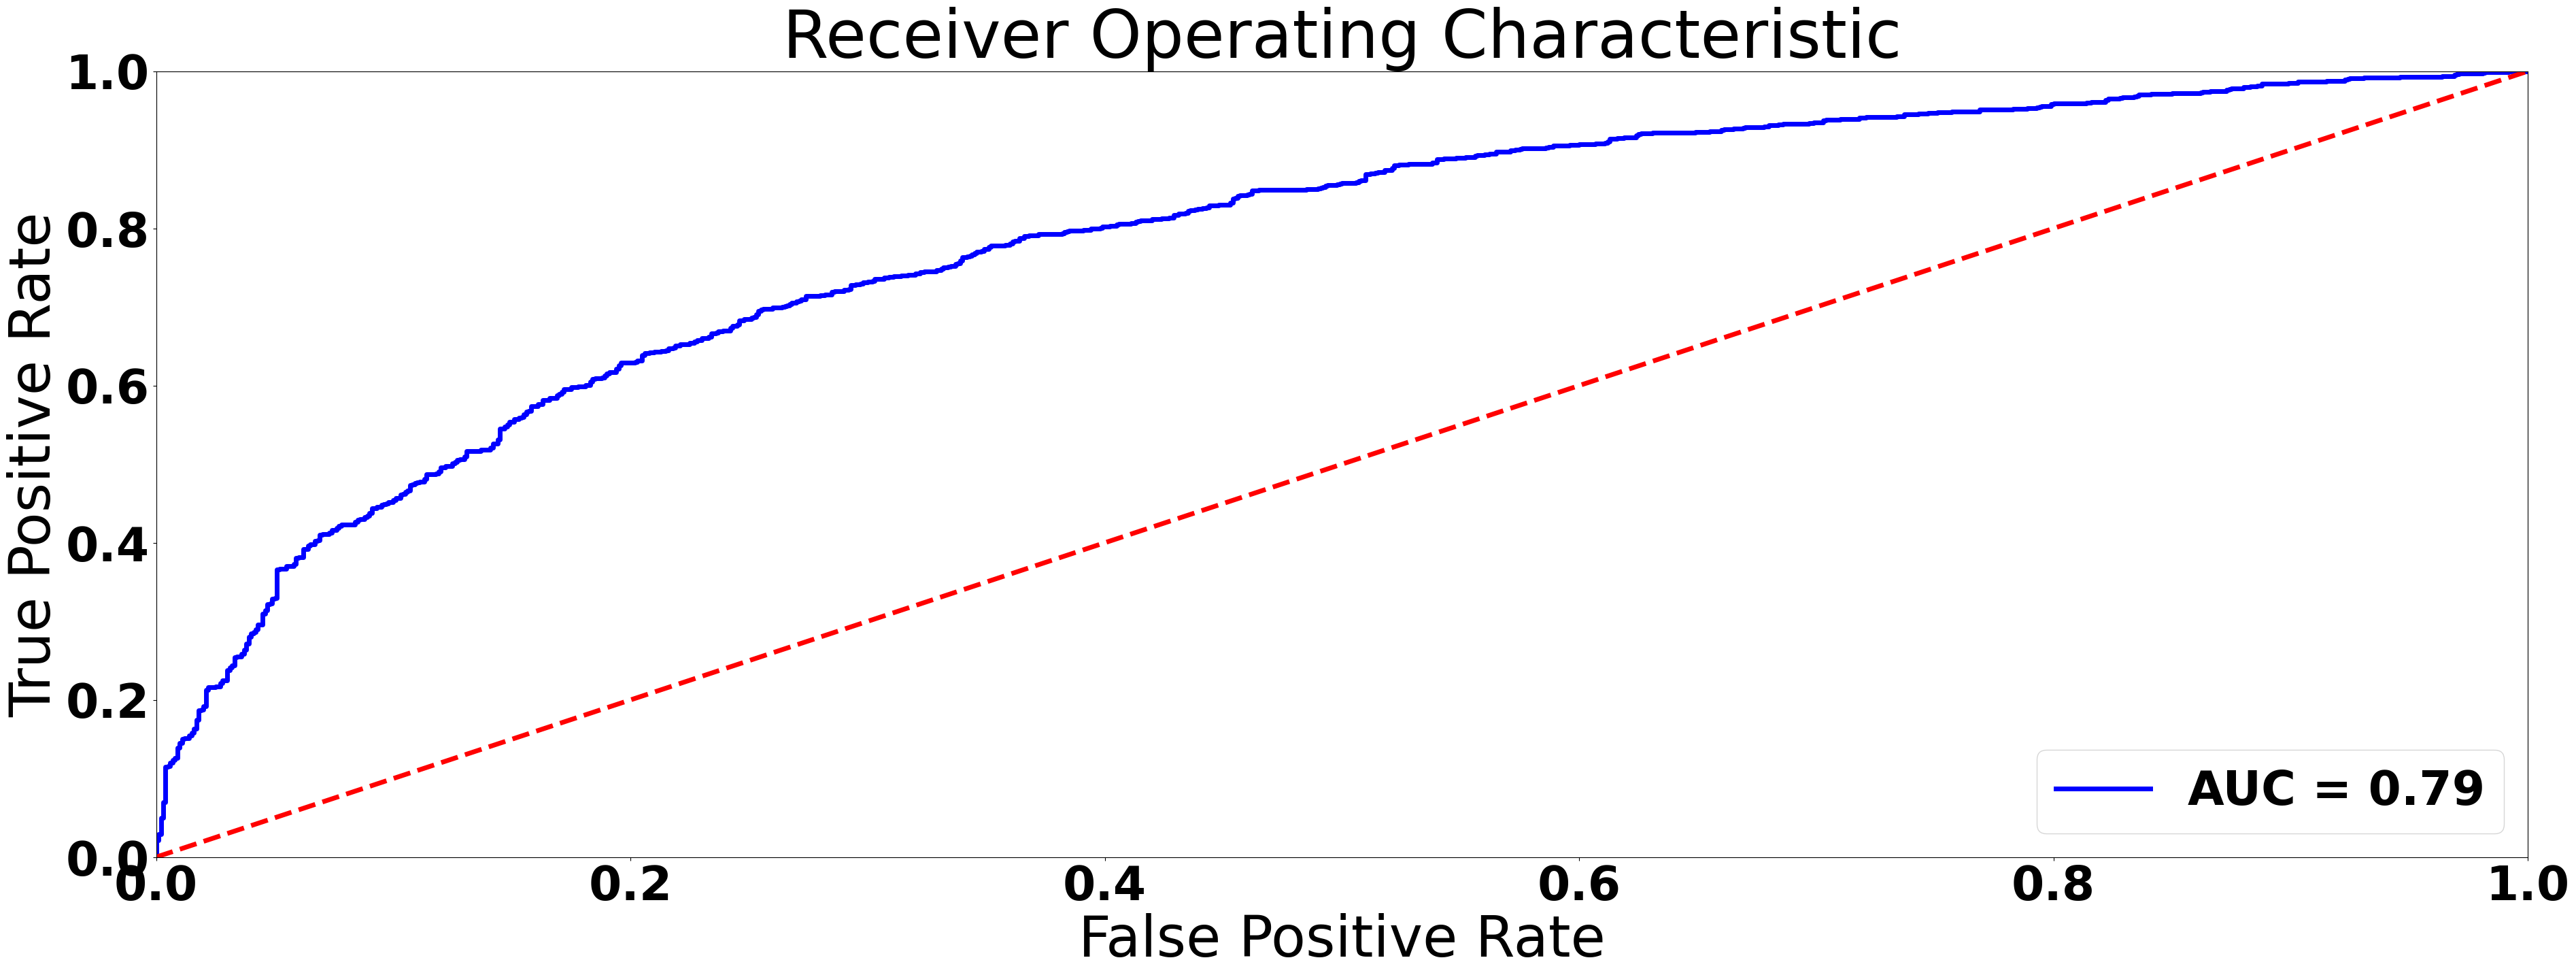

The accuracy score is": 0.721
The f1 score is": 0.714
The recall score is": 0.697
The precision score is": 0.732
The f2 score is": 0.704
The Kappa score is": 0.442
                  precision    recall  f1-score   support

class 0 (Normal)       0.71      0.74      0.73      1000
 class 1 (Fraud)       0.73      0.70      0.71      1000

        accuracy                           0.72      2000
       macro avg       0.72      0.72      0.72      2000
    weighted avg       0.72      0.72      0.72      2000



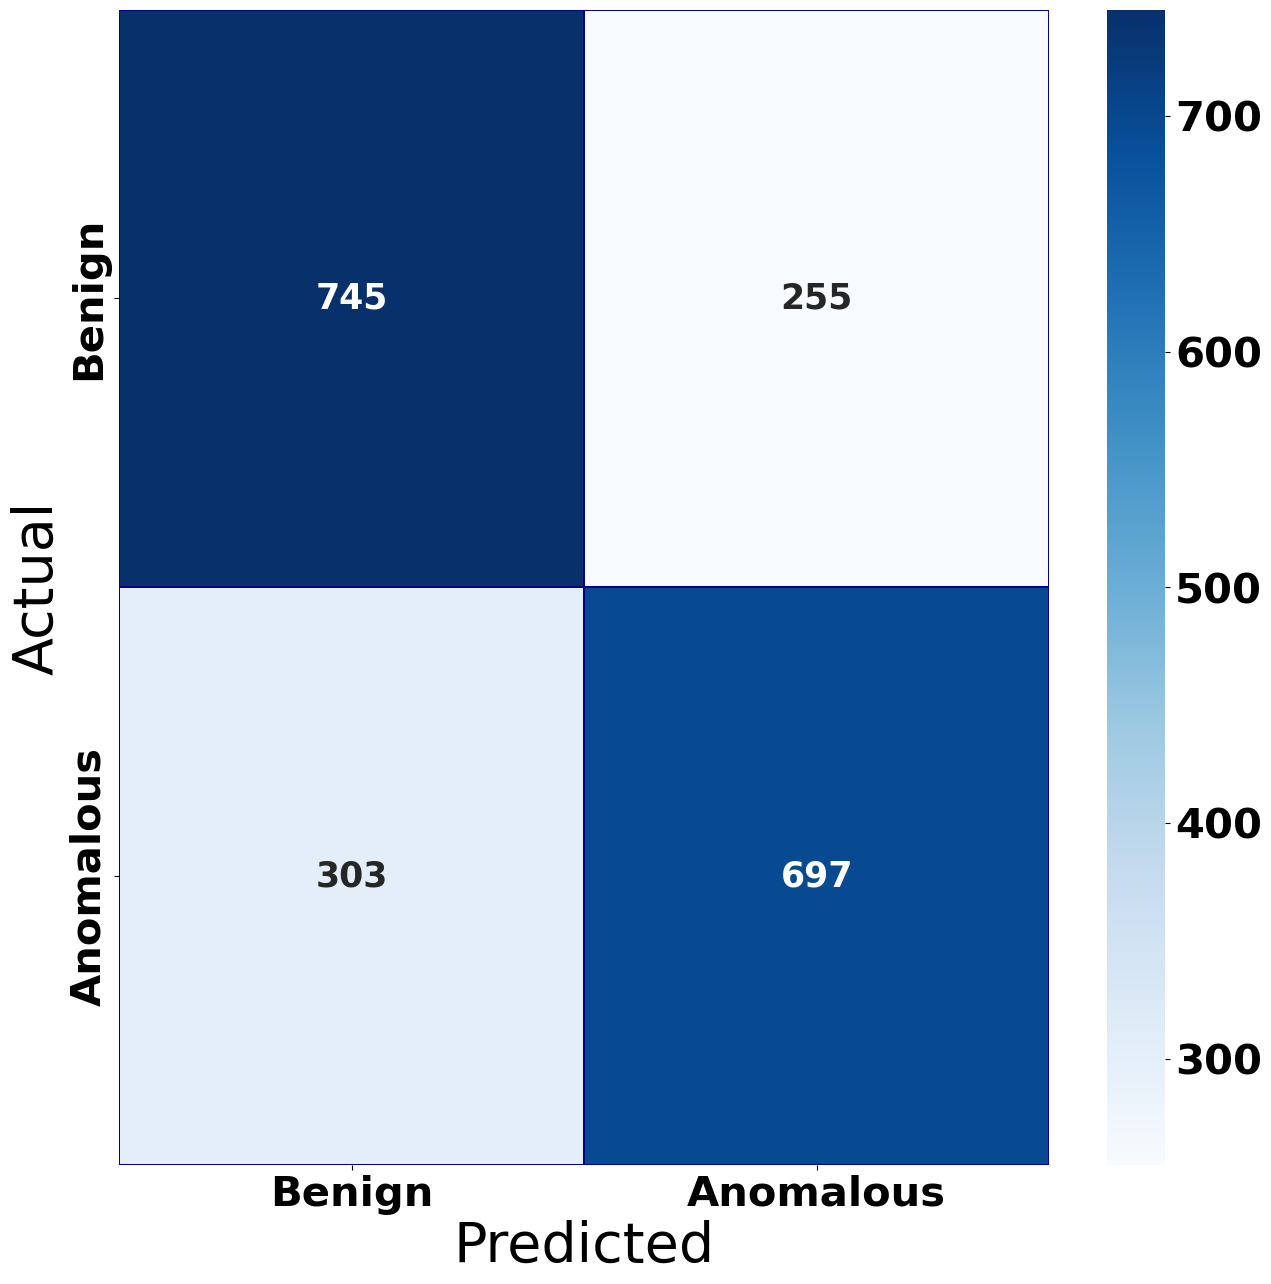

In [33]:
train_amount = 2000

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)

# train_amount = 1500

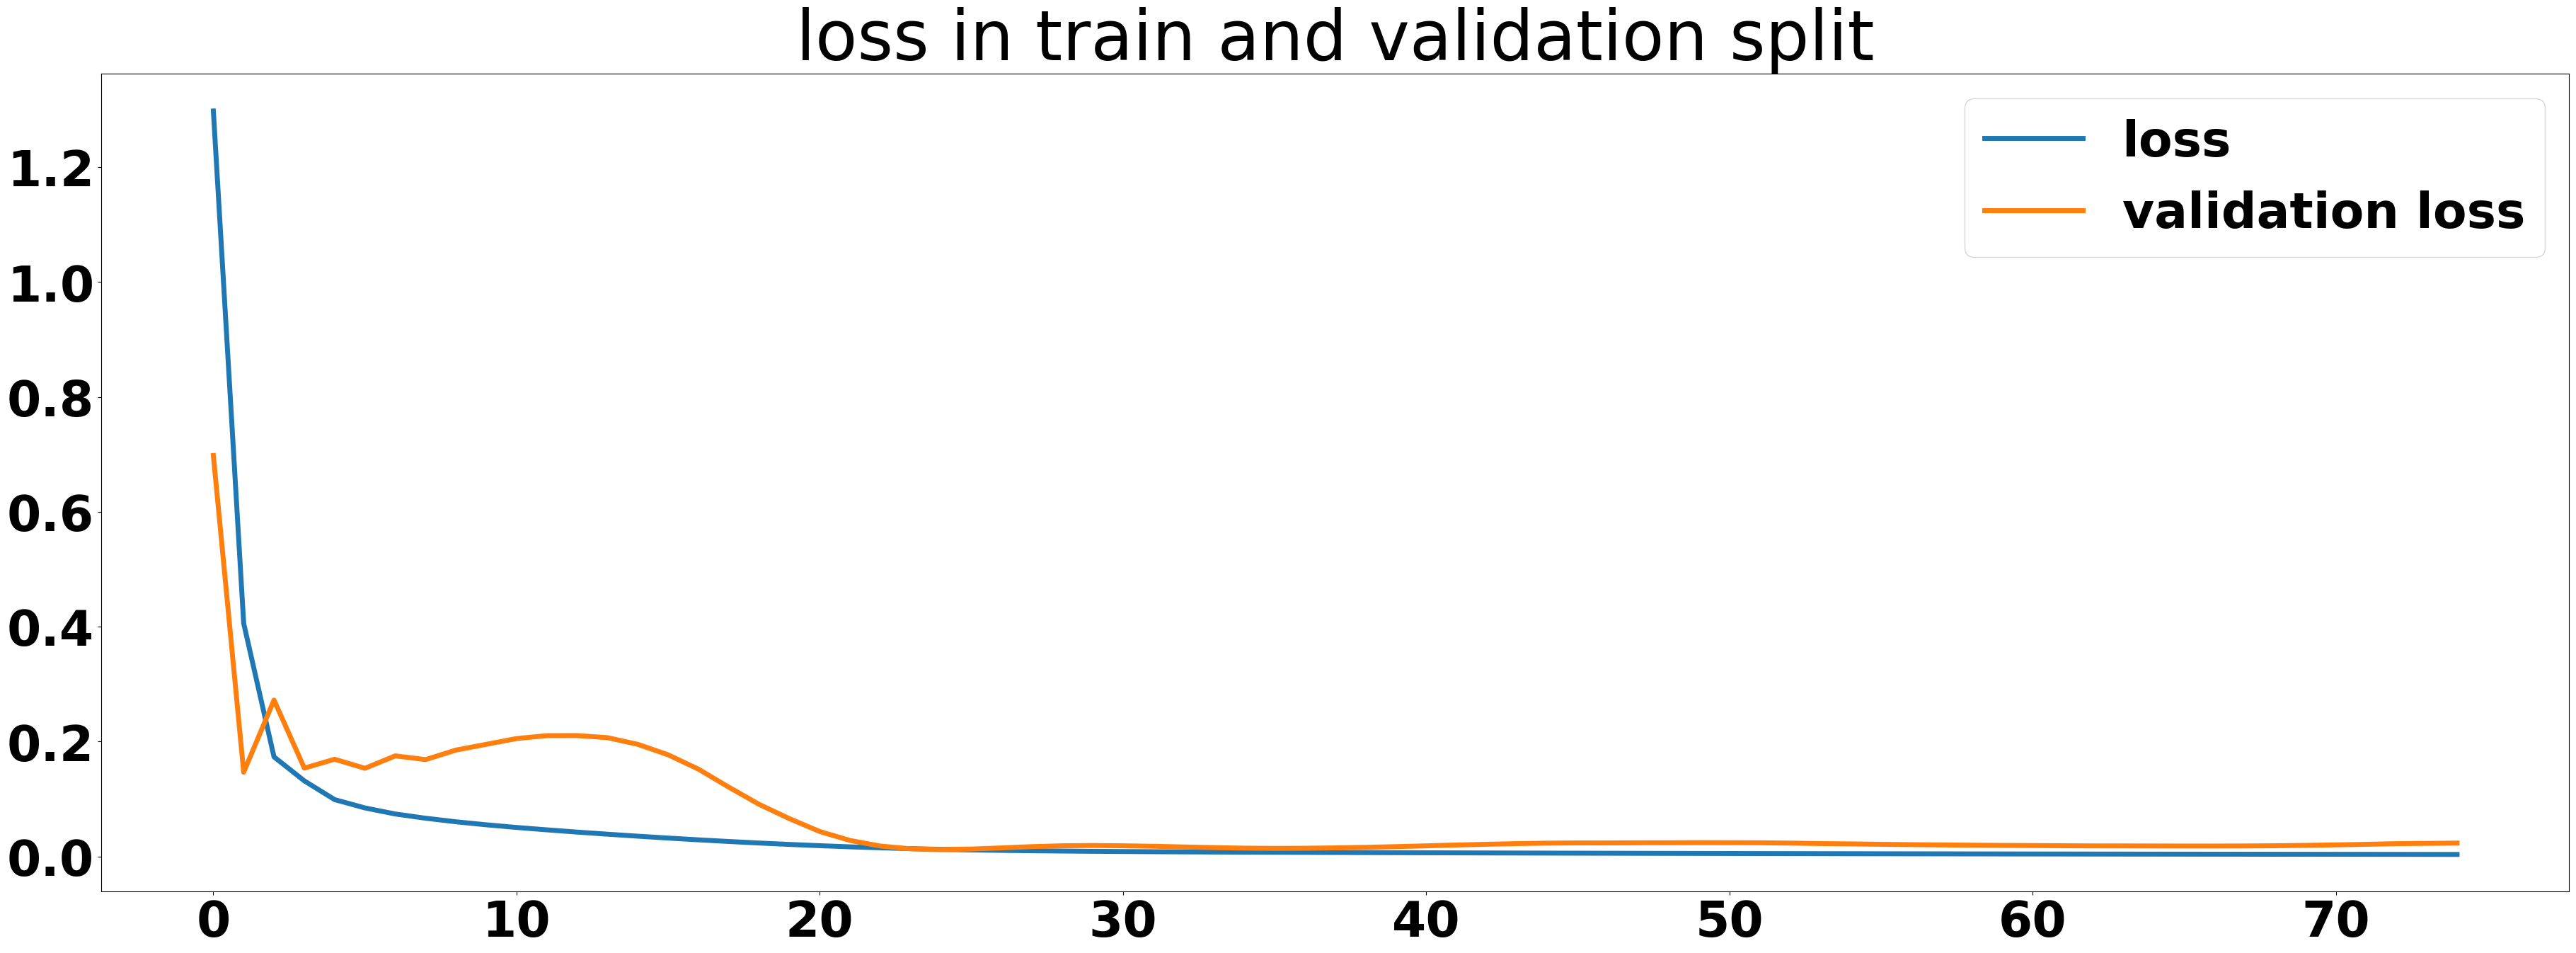

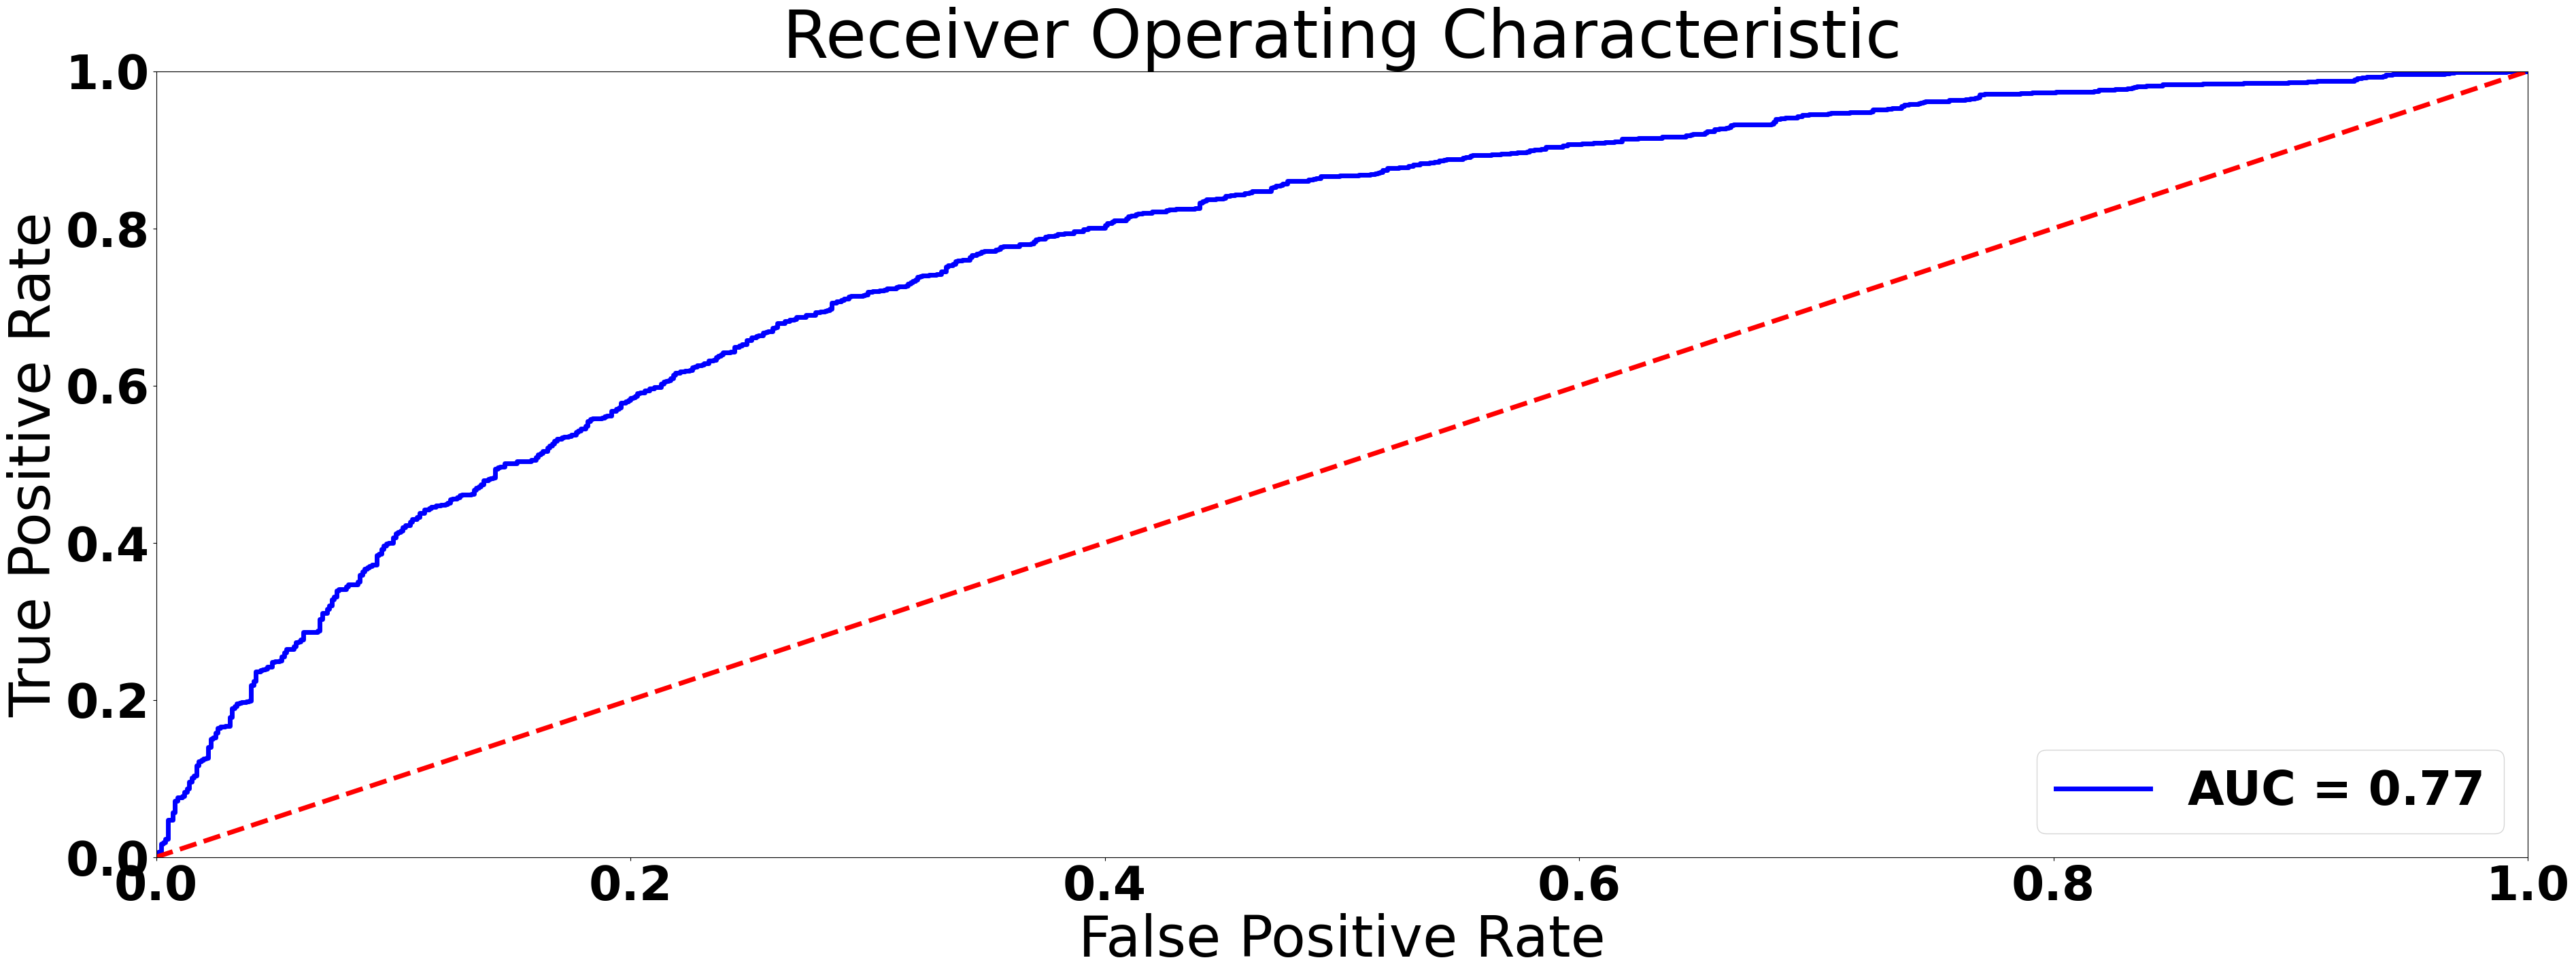

The accuracy score is": 0.711
The f1 score is": 0.727
The recall score is": 0.768
The precision score is": 0.689
The f2 score is": 0.751
The Kappa score is": 0.422
                  precision    recall  f1-score   support

class 0 (Normal)       0.74      0.65      0.69      1000
 class 1 (Fraud)       0.69      0.77      0.73      1000

        accuracy                           0.71      2000
       macro avg       0.71      0.71      0.71      2000
    weighted avg       0.71      0.71      0.71      2000



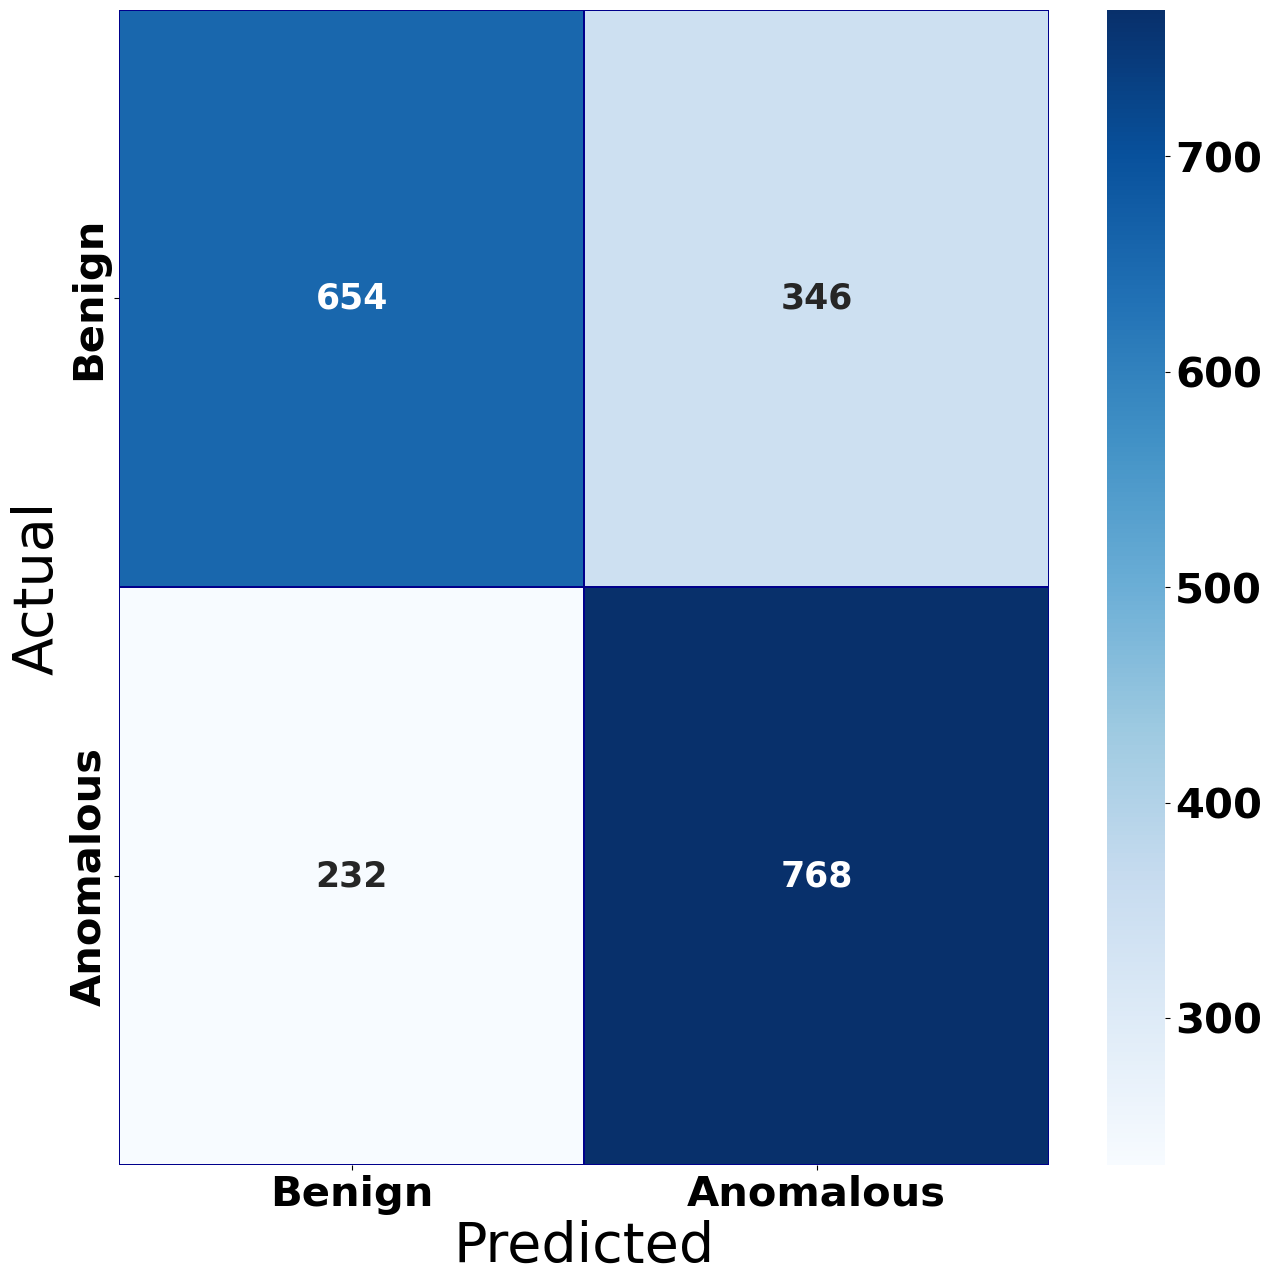

In [34]:
train_amount = 1500

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)

# train_amount = 1000

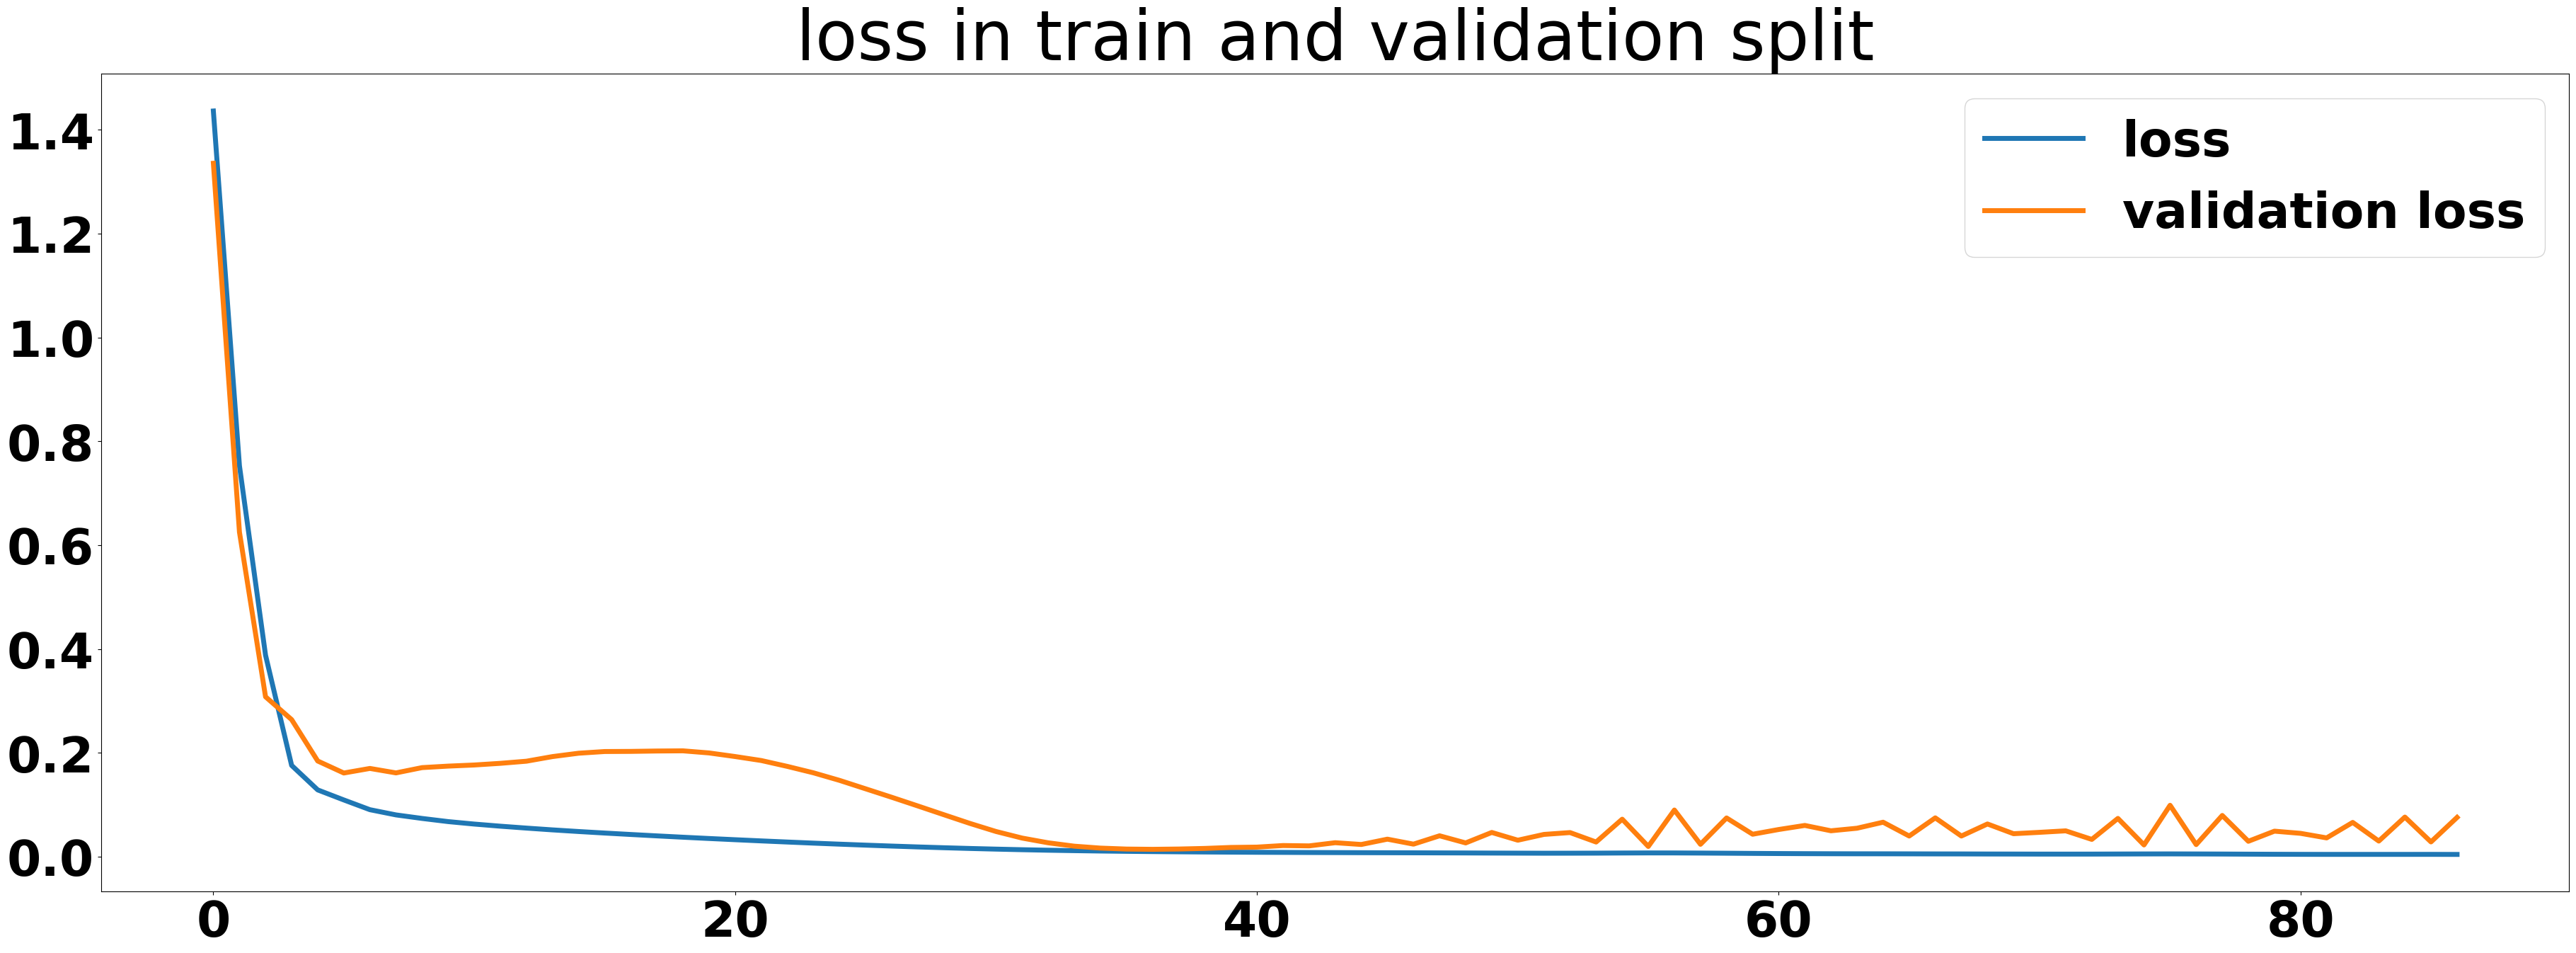

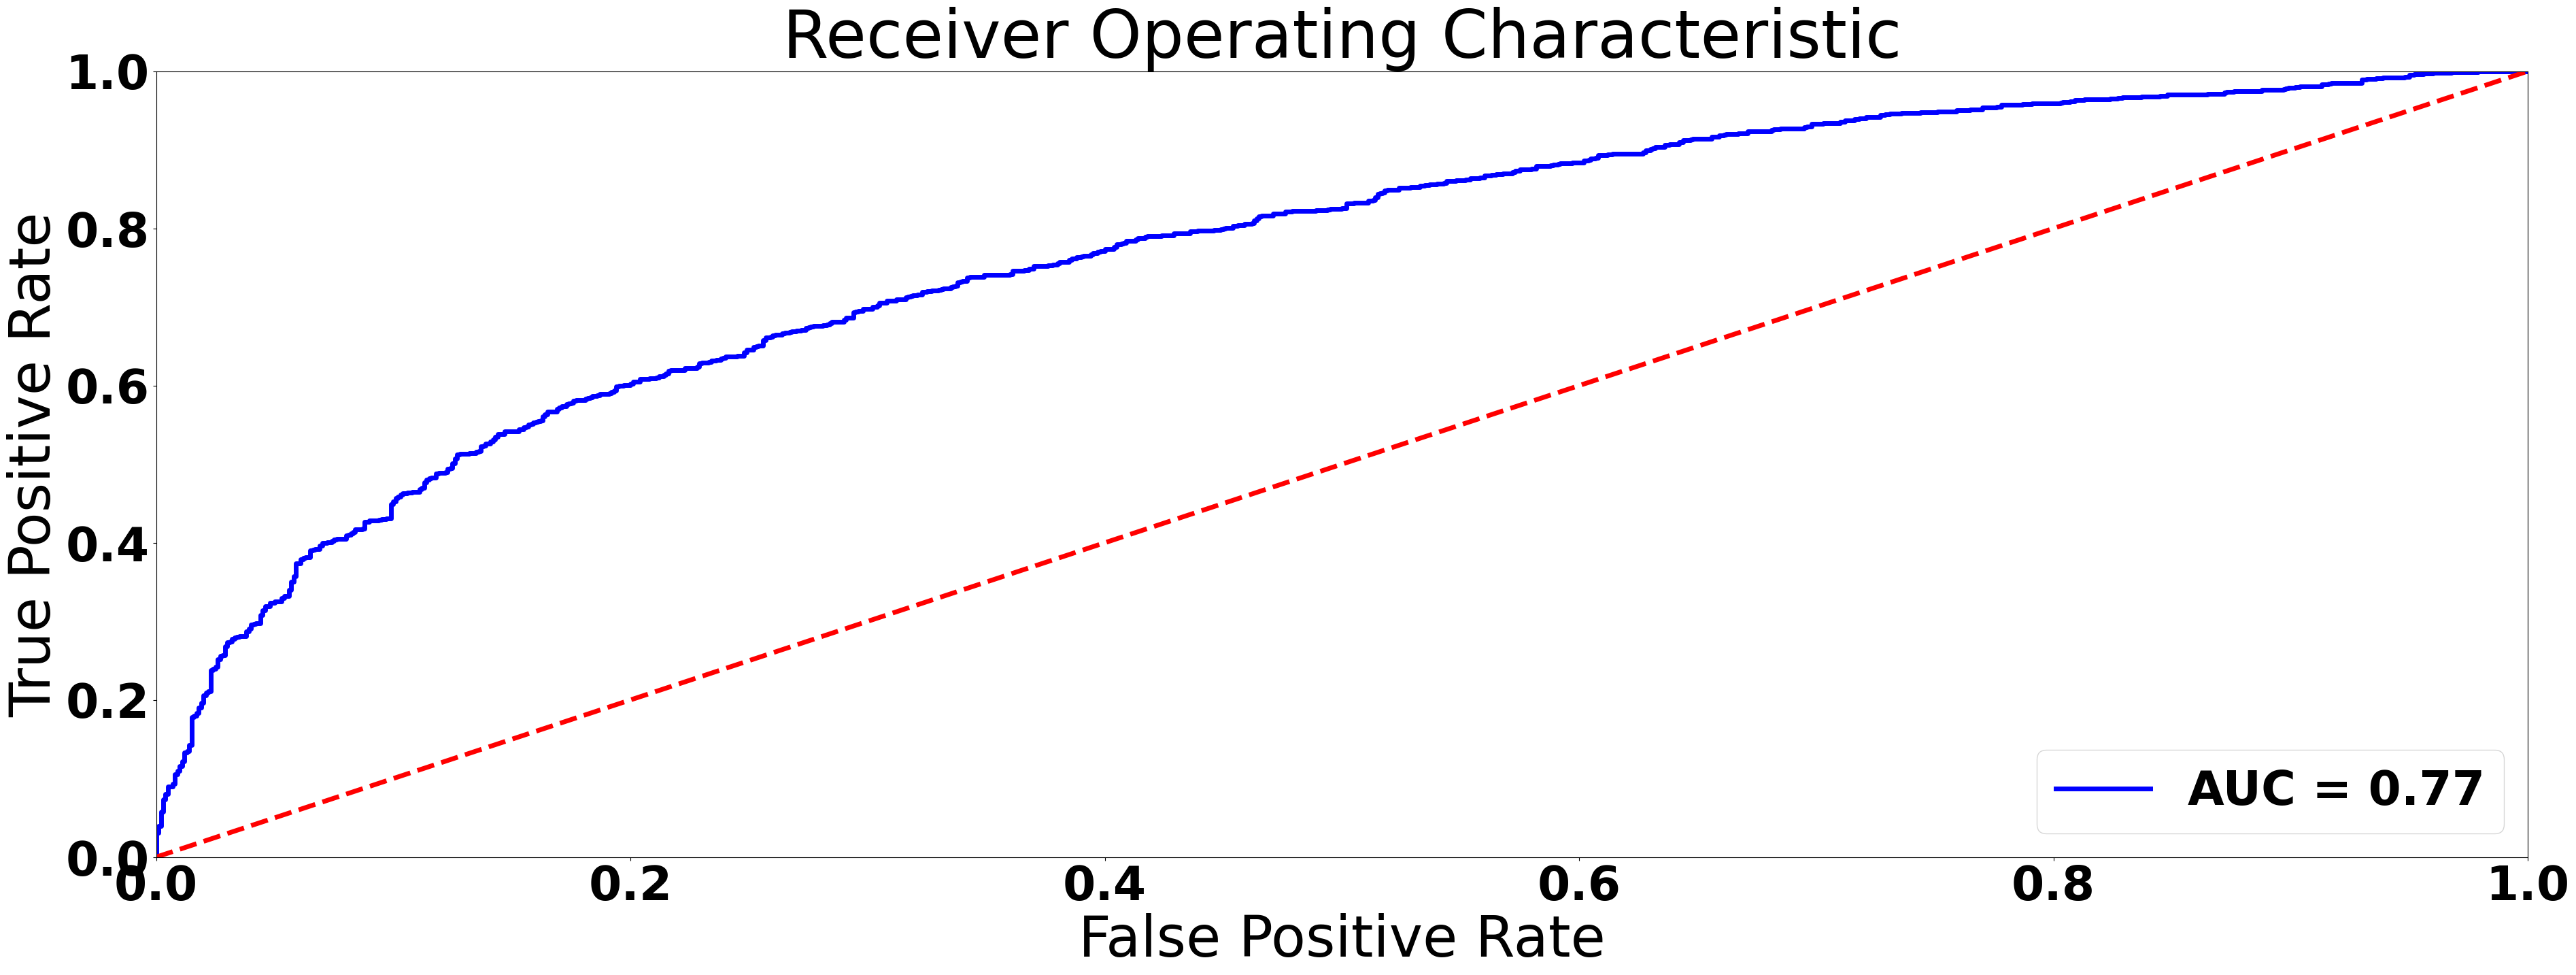

The accuracy score is": 0.703
The f1 score is": 0.661
The recall score is": 0.581
The precision score is": 0.768
The f2 score is": 0.611
The Kappa score is": 0.405
                  precision    recall  f1-score   support

class 0 (Normal)       0.66      0.82      0.73      1000
 class 1 (Fraud)       0.77      0.58      0.66      1000

        accuracy                           0.70      2000
       macro avg       0.72      0.70      0.70      2000
    weighted avg       0.72      0.70      0.70      2000



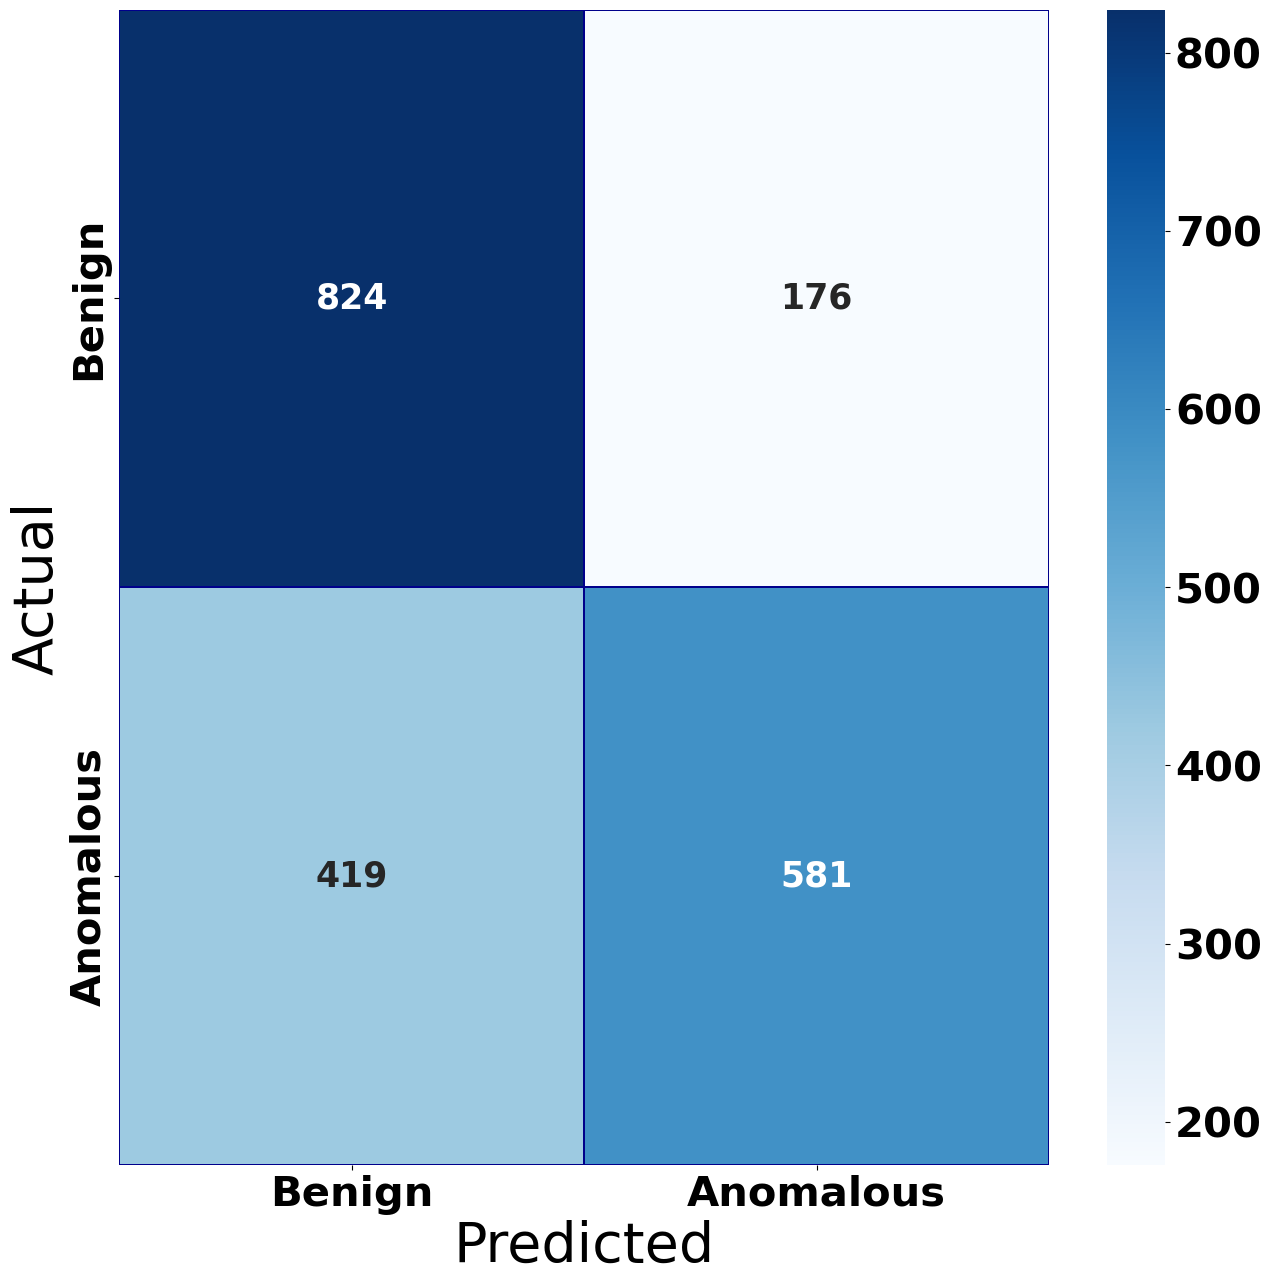

In [35]:
train_amount = 1000

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)

# train_amount = 500

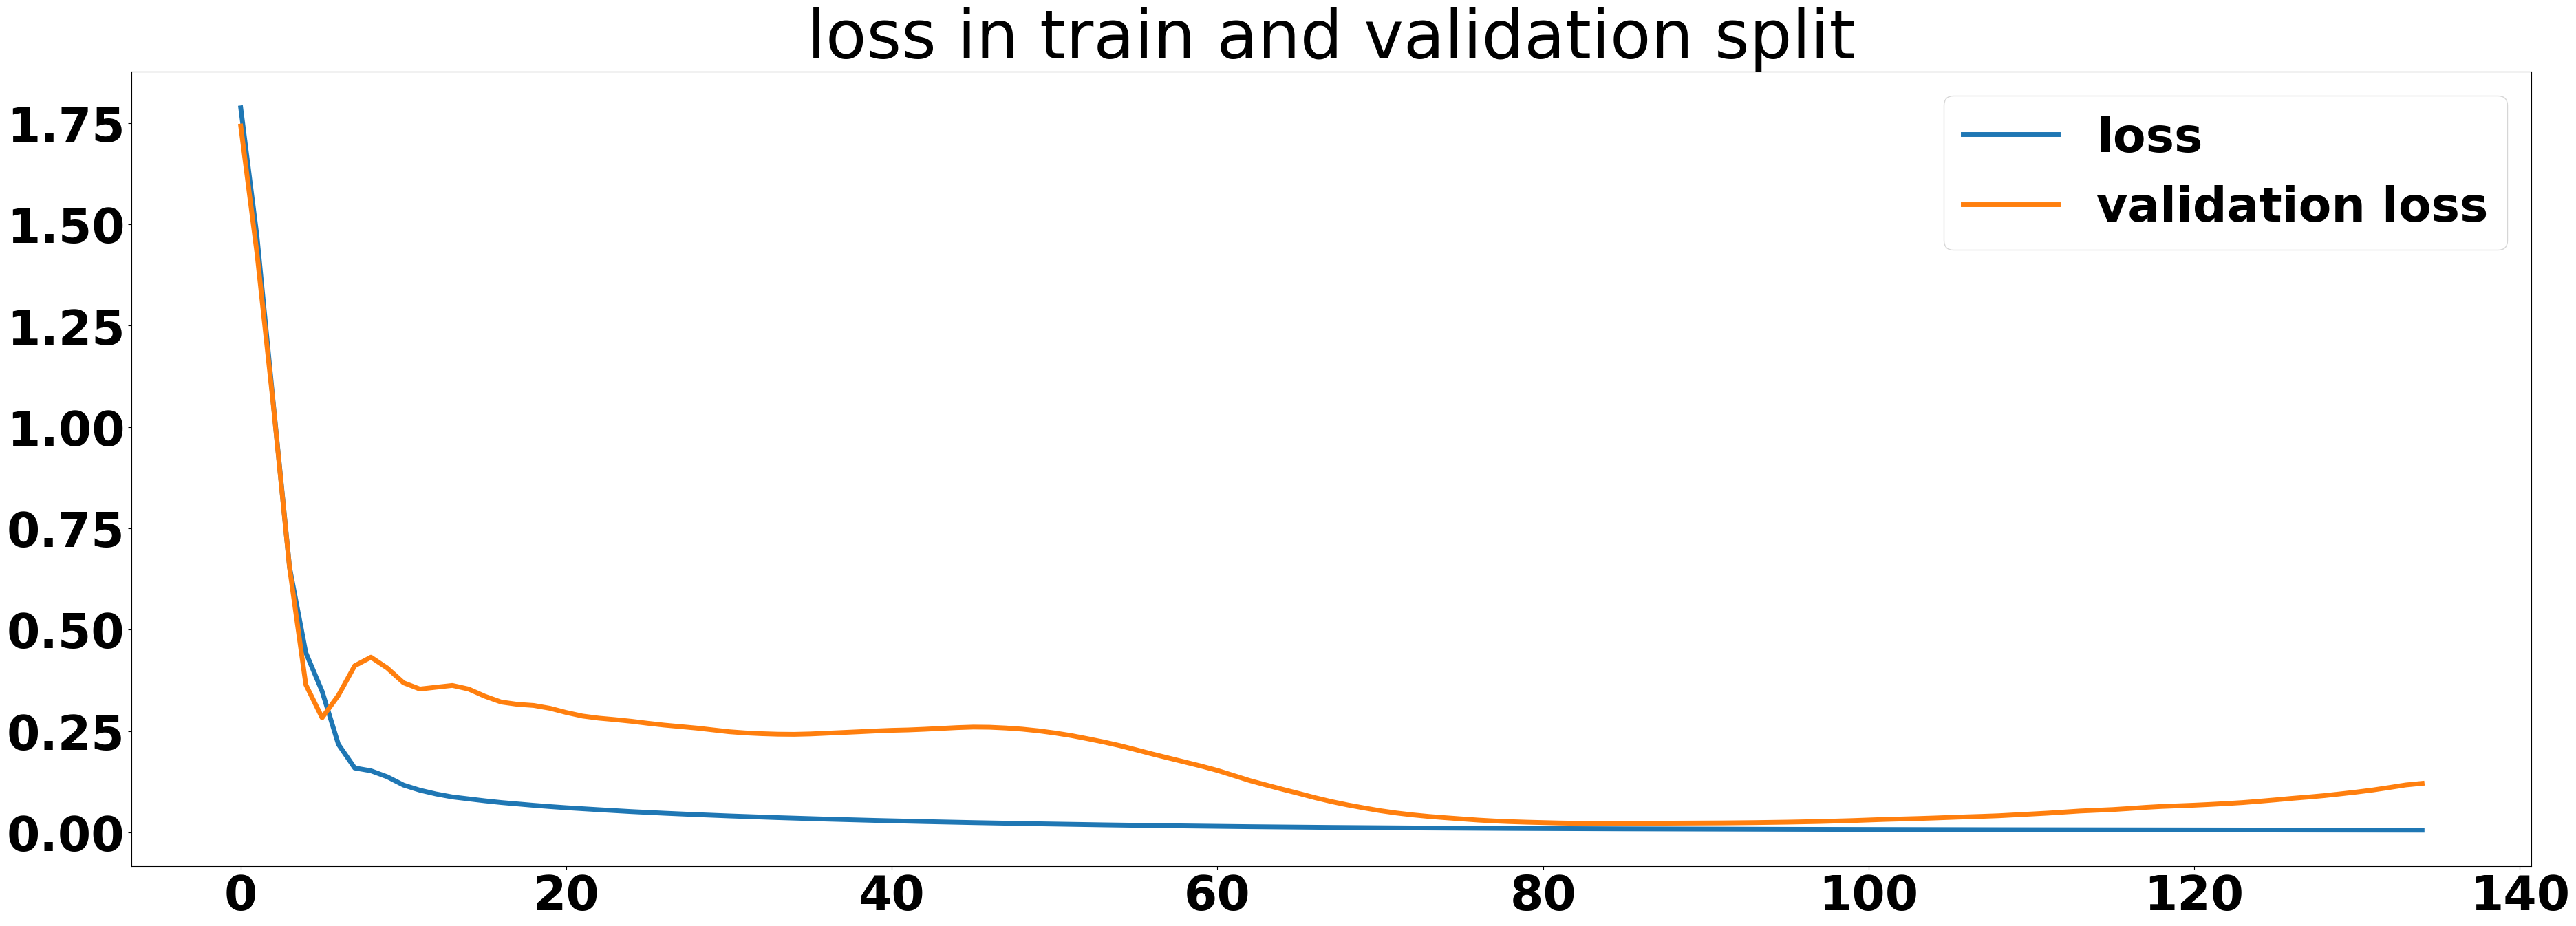

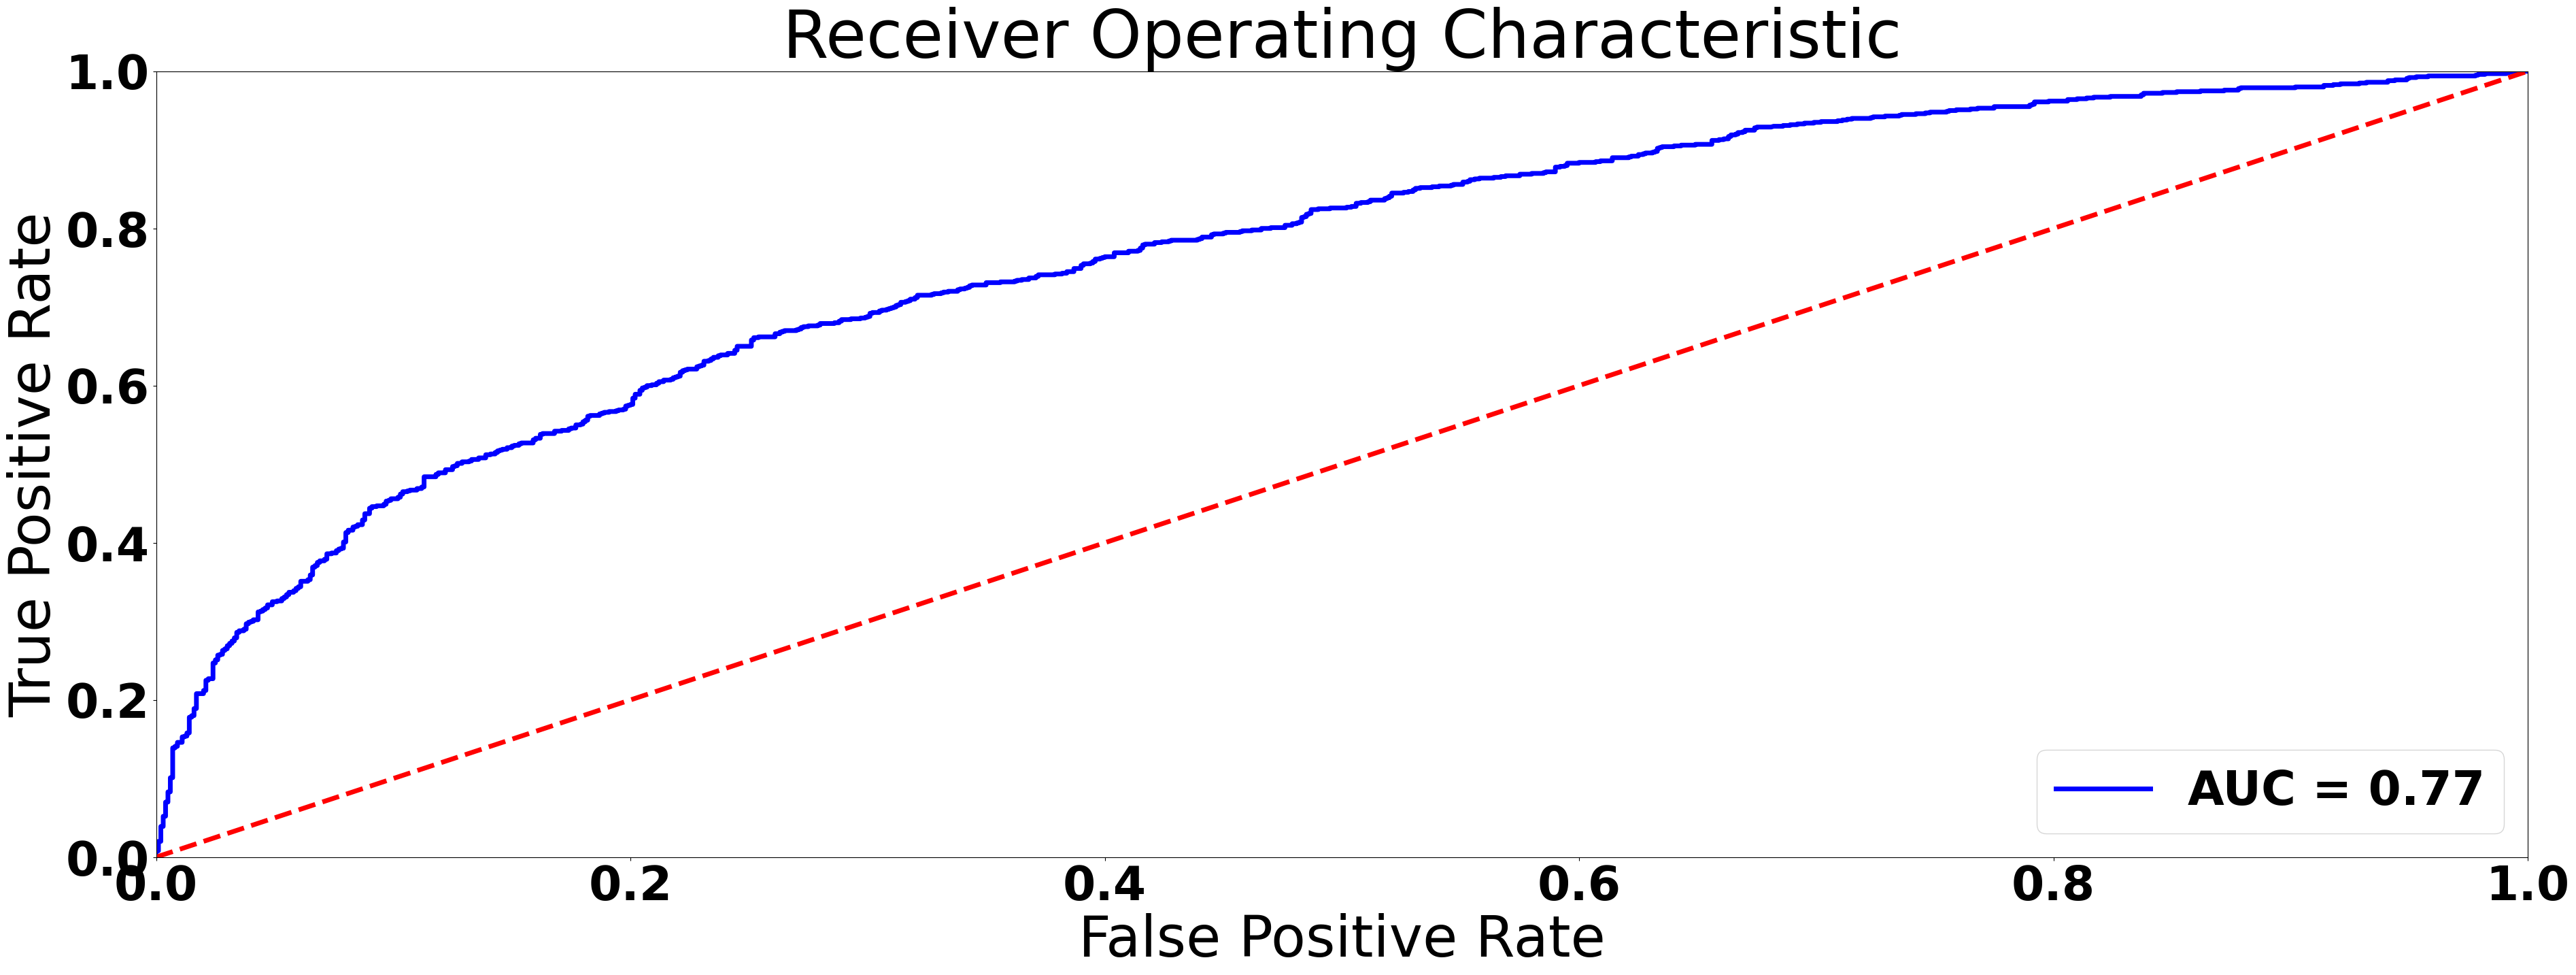

The accuracy score is": 0.704
The f1 score is": 0.690
The recall score is": 0.660
The precision score is": 0.724
The f2 score is": 0.672
The Kappa score is": 0.408
                  precision    recall  f1-score   support

class 0 (Normal)       0.69      0.75      0.72      1000
 class 1 (Fraud)       0.72      0.66      0.69      1000

        accuracy                           0.70      2000
       macro avg       0.71      0.70      0.70      2000
    weighted avg       0.71      0.70      0.70      2000



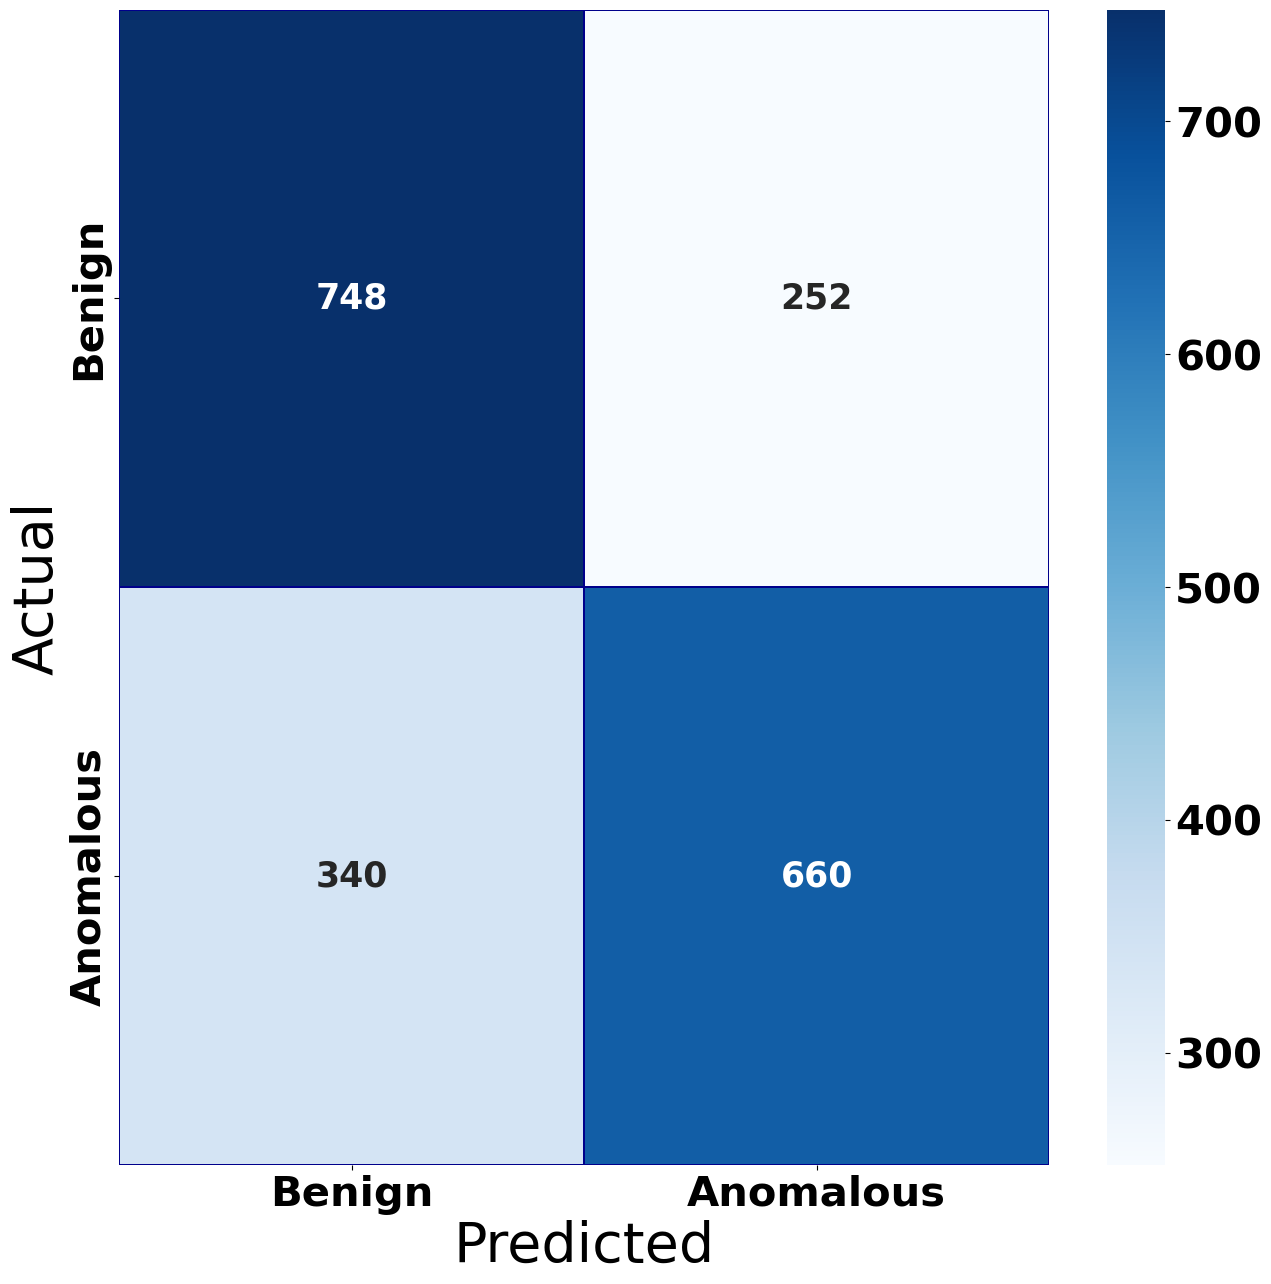

In [36]:
train_amount = 500

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)

# train_amount = 100

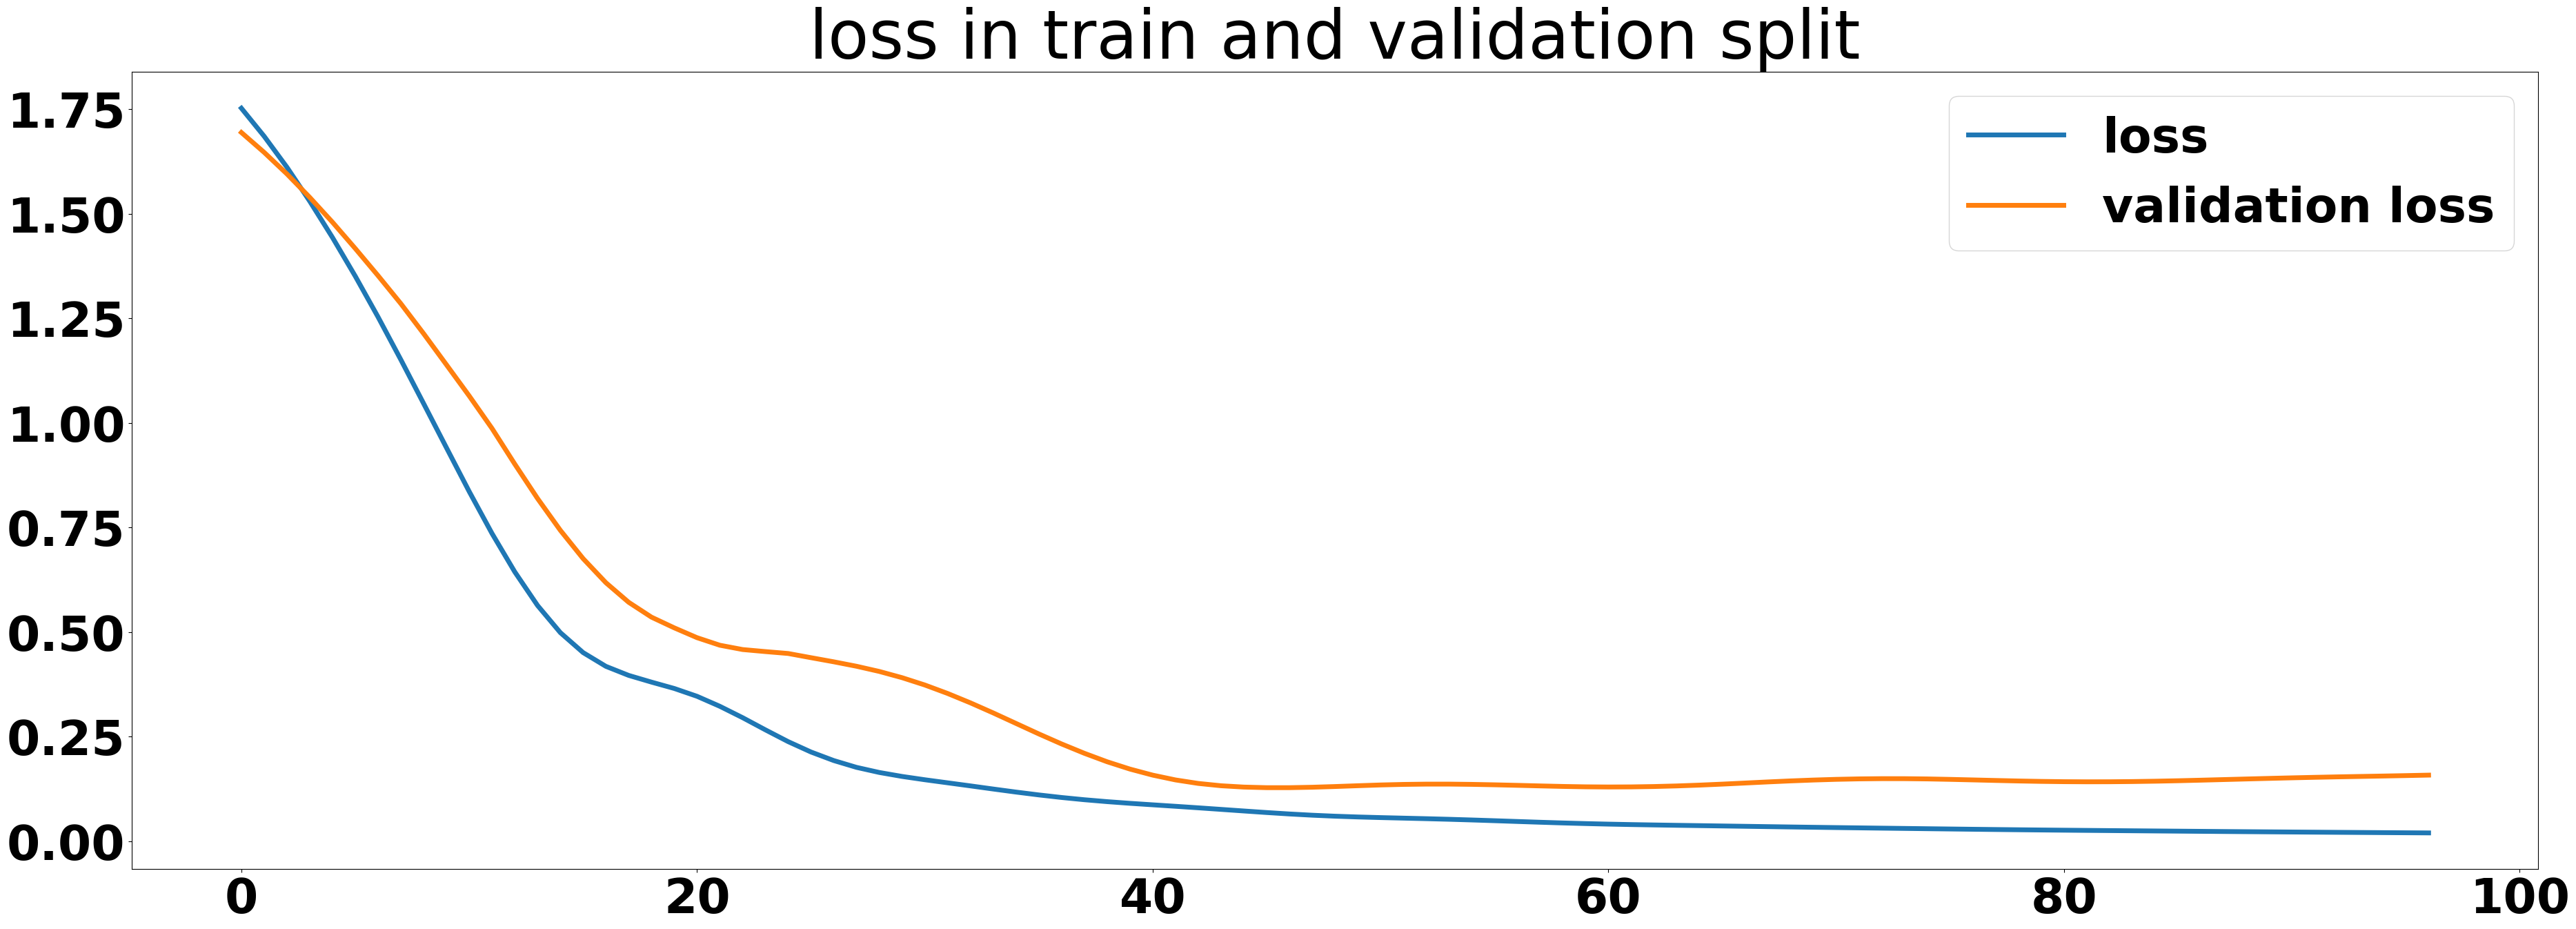

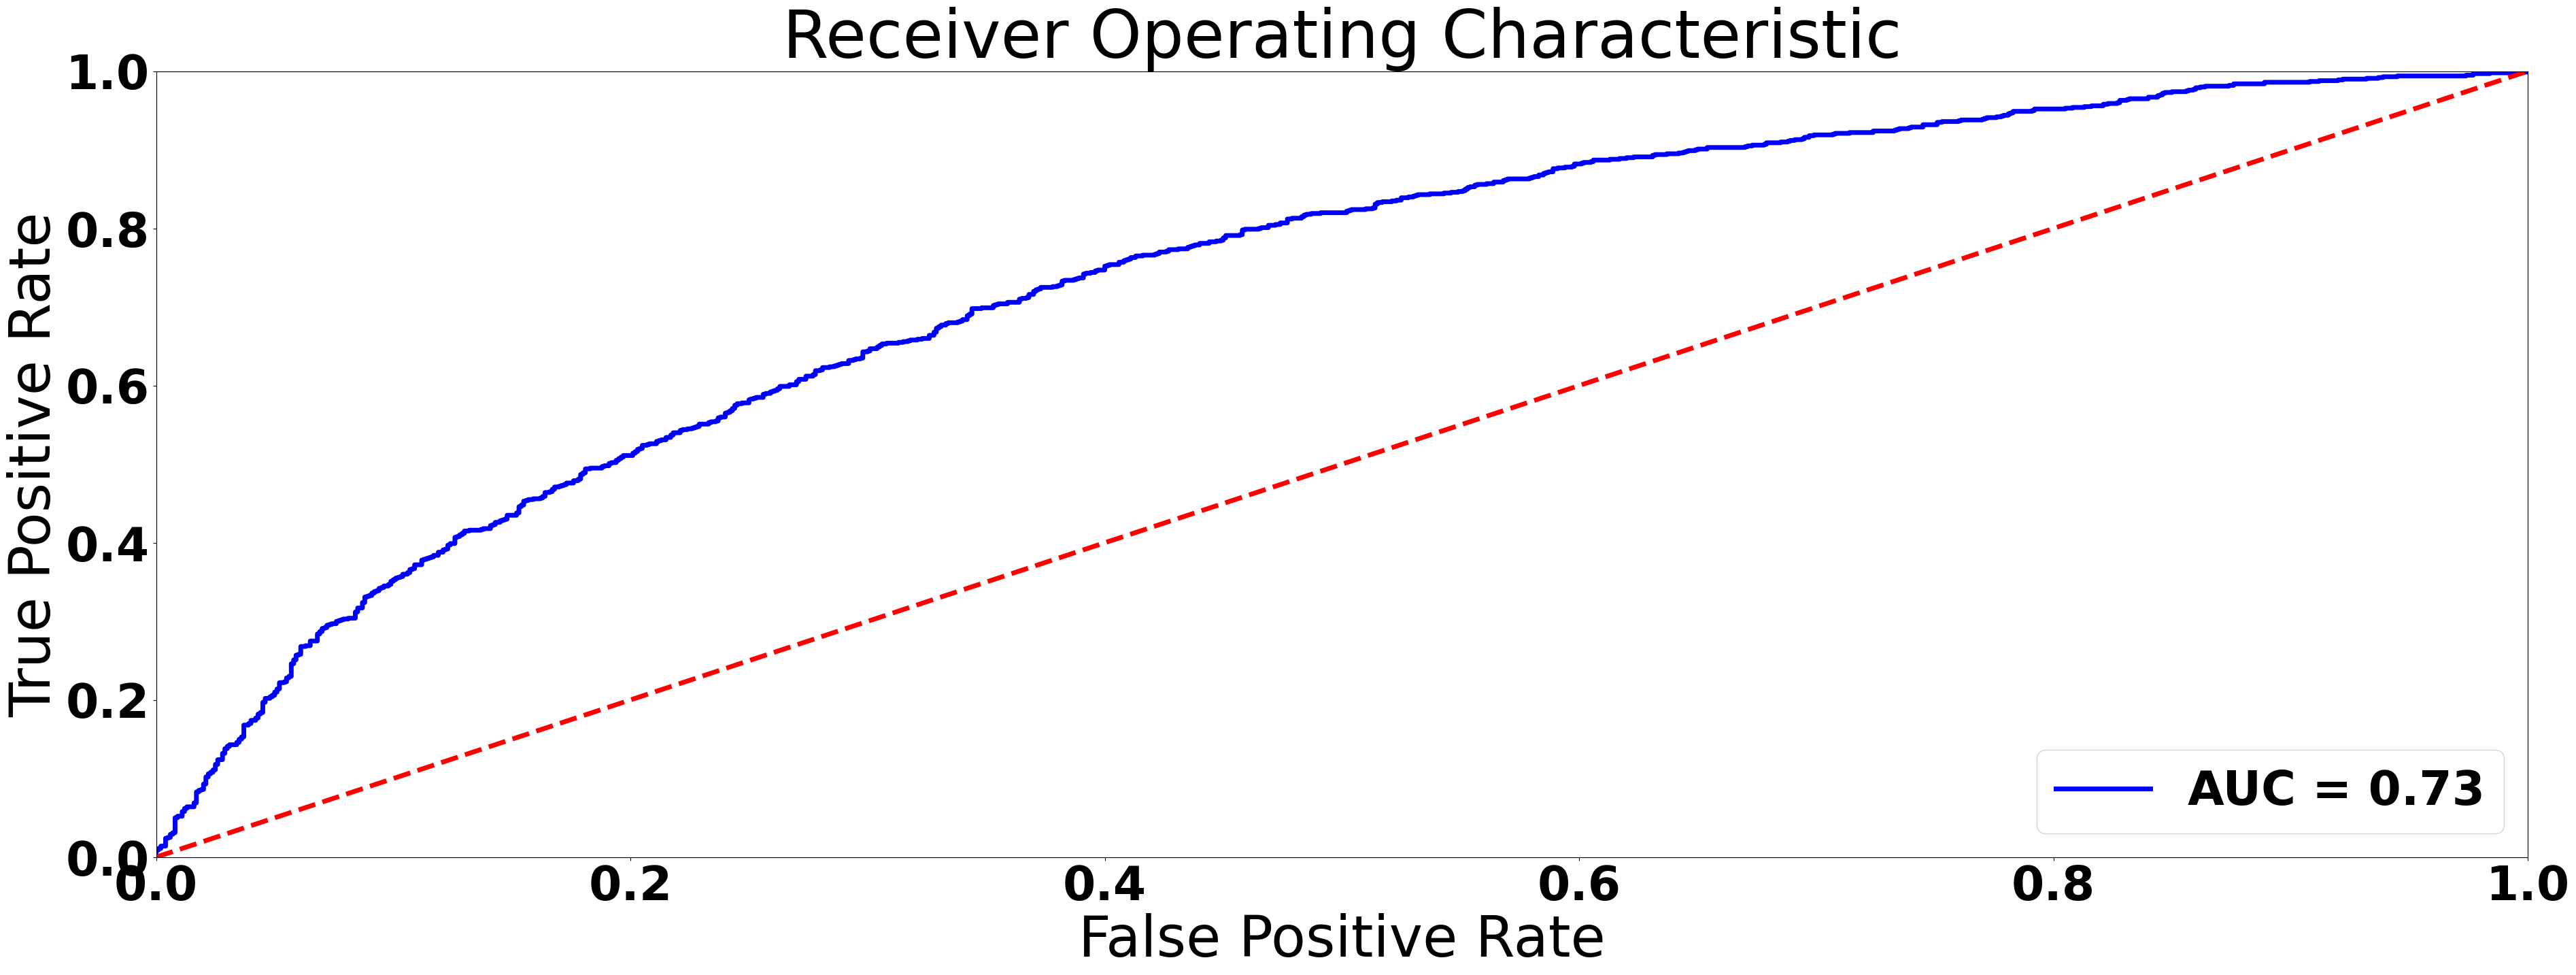

The accuracy score is": 0.676
The f1 score is": 0.683
The recall score is": 0.697
The precision score is": 0.670
The f2 score is": 0.691
The Kappa score is": 0.353
                  precision    recall  f1-score   support

class 0 (Normal)       0.68      0.66      0.67      1000
 class 1 (Fraud)       0.67      0.70      0.68      1000

        accuracy                           0.68      2000
       macro avg       0.68      0.68      0.68      2000
    weighted avg       0.68      0.68      0.68      2000



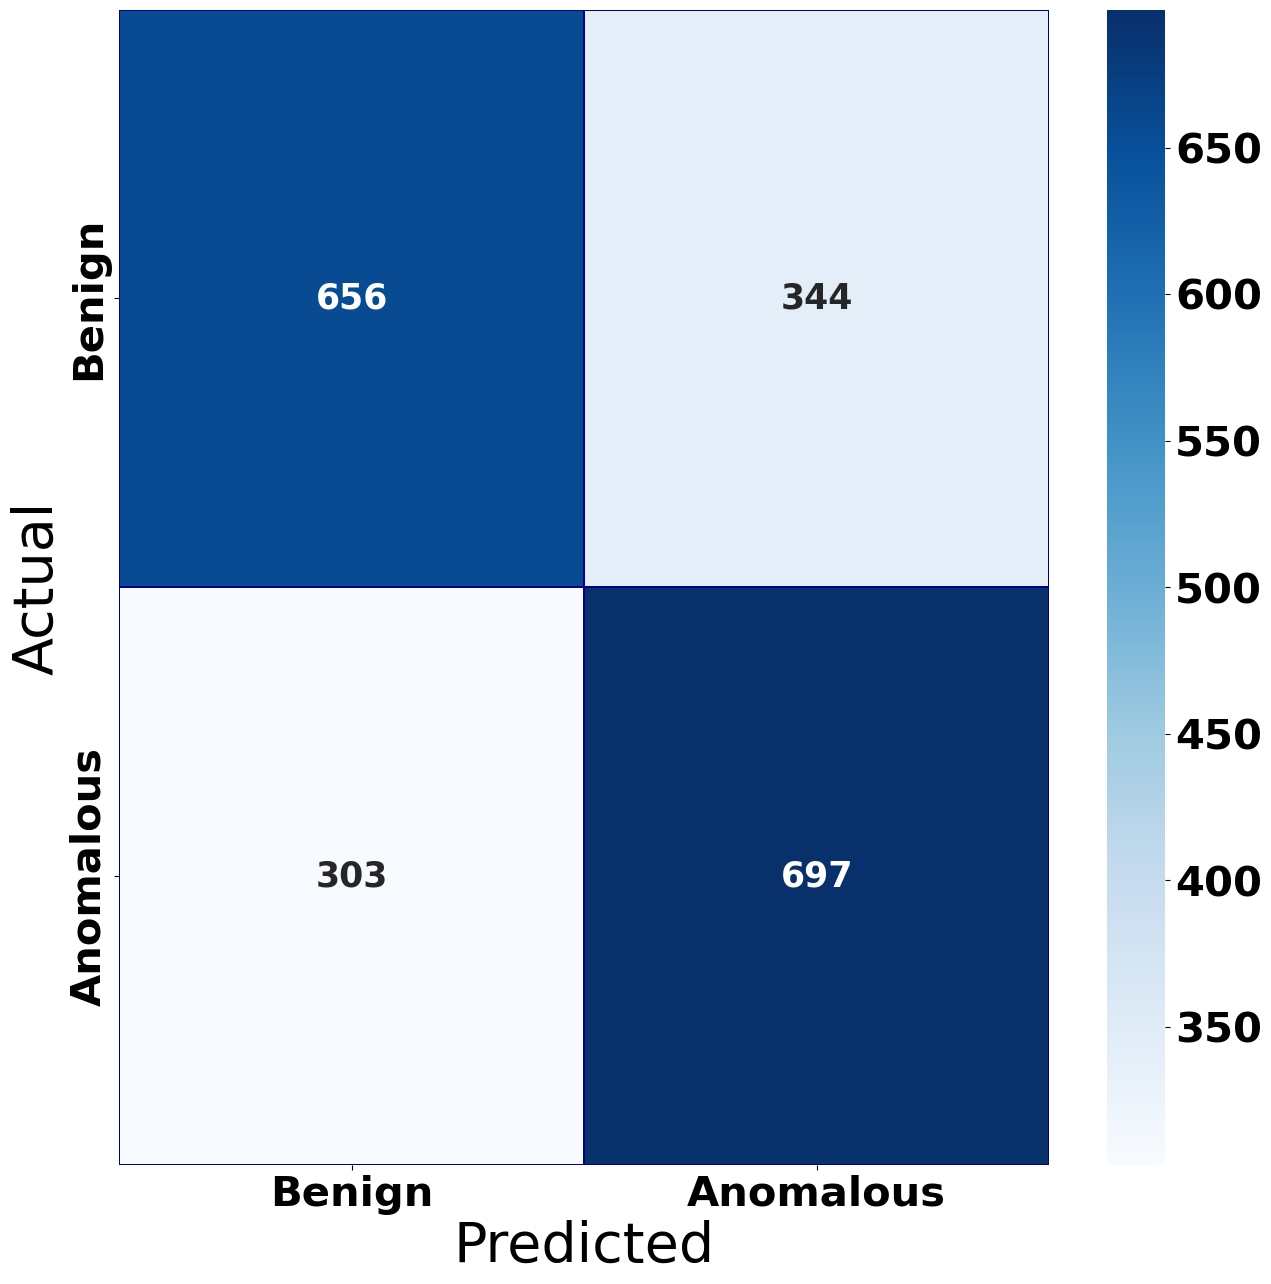

In [37]:
train_amount = 100

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)

# train_amount = 10

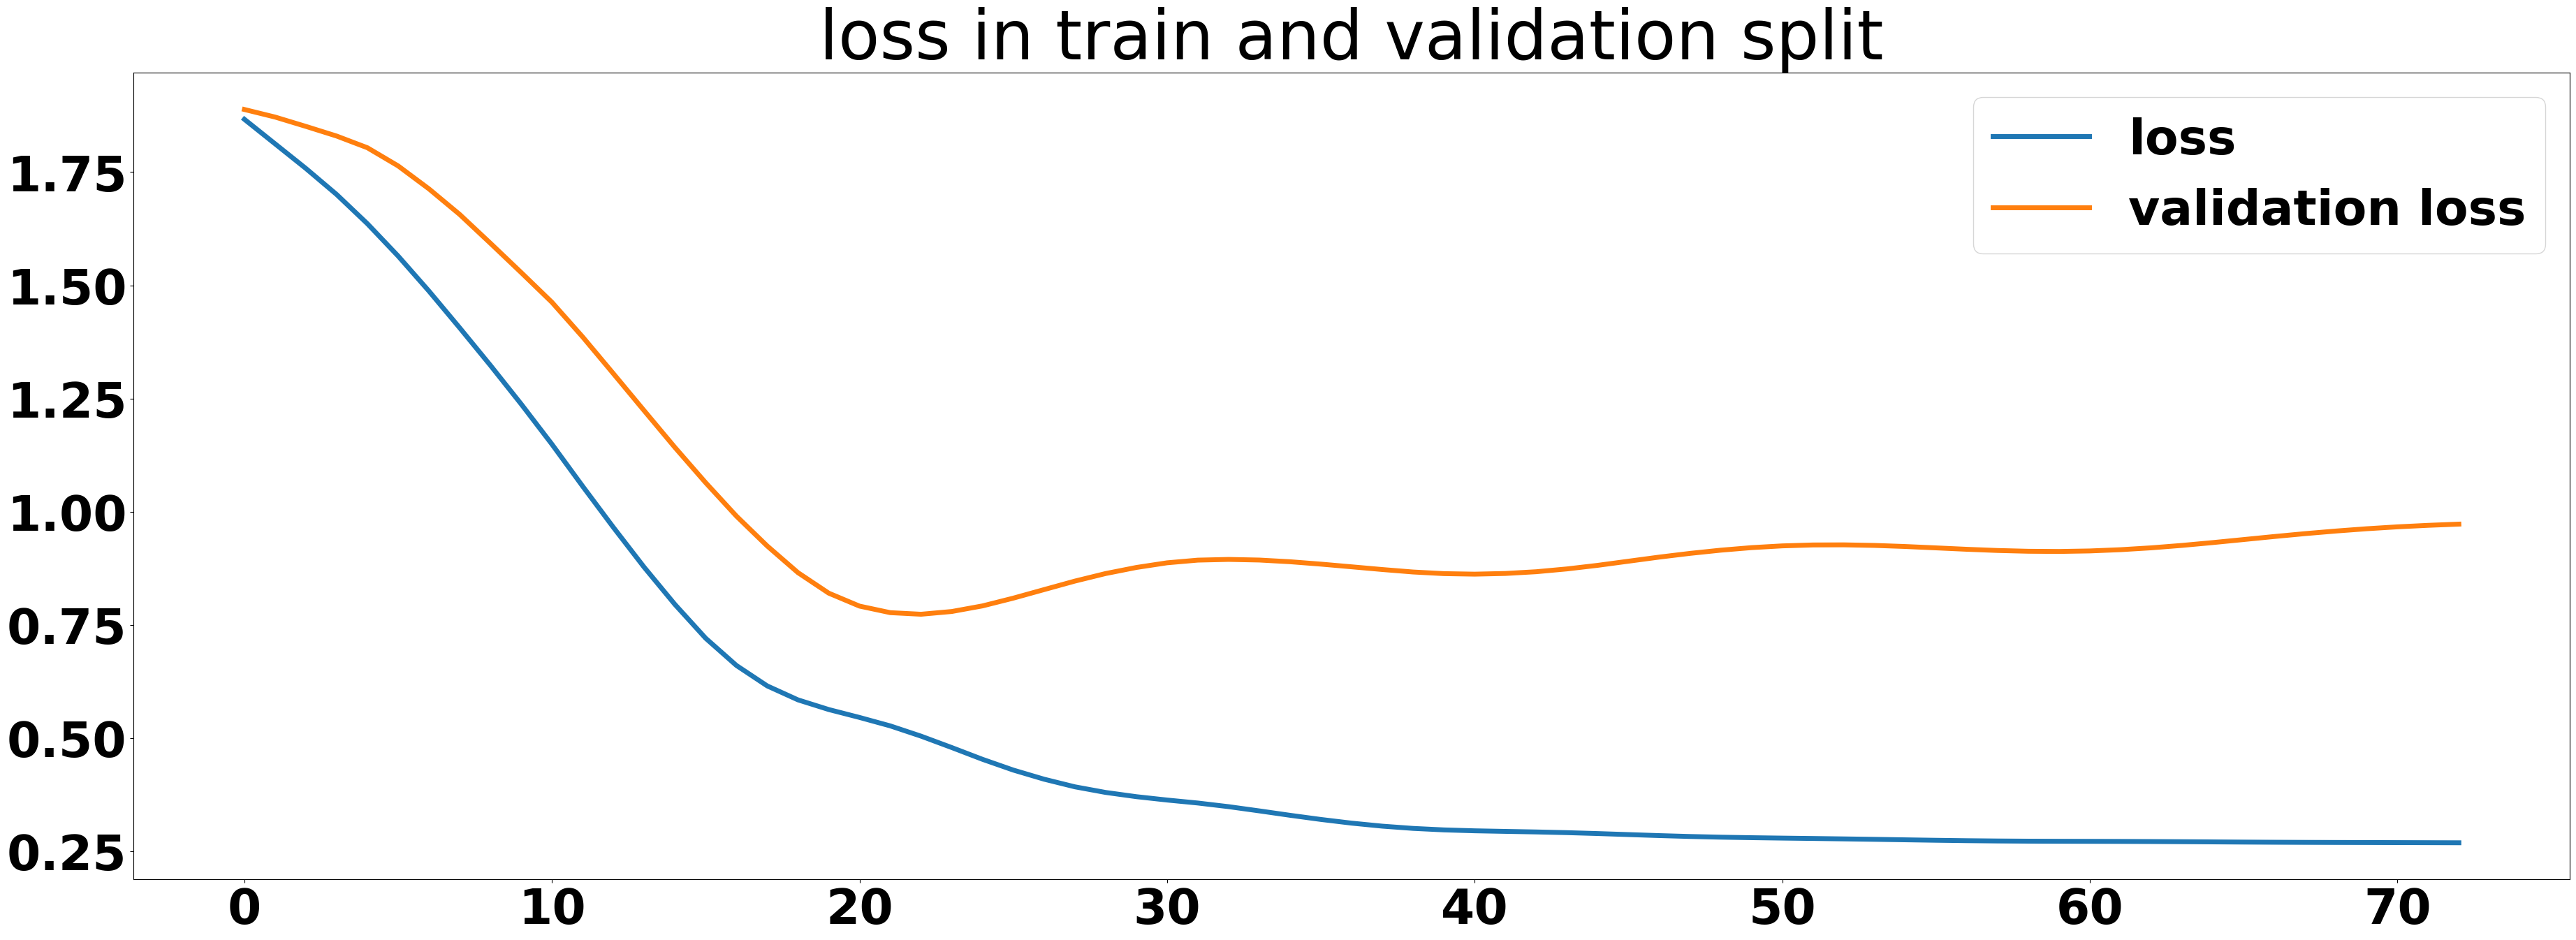

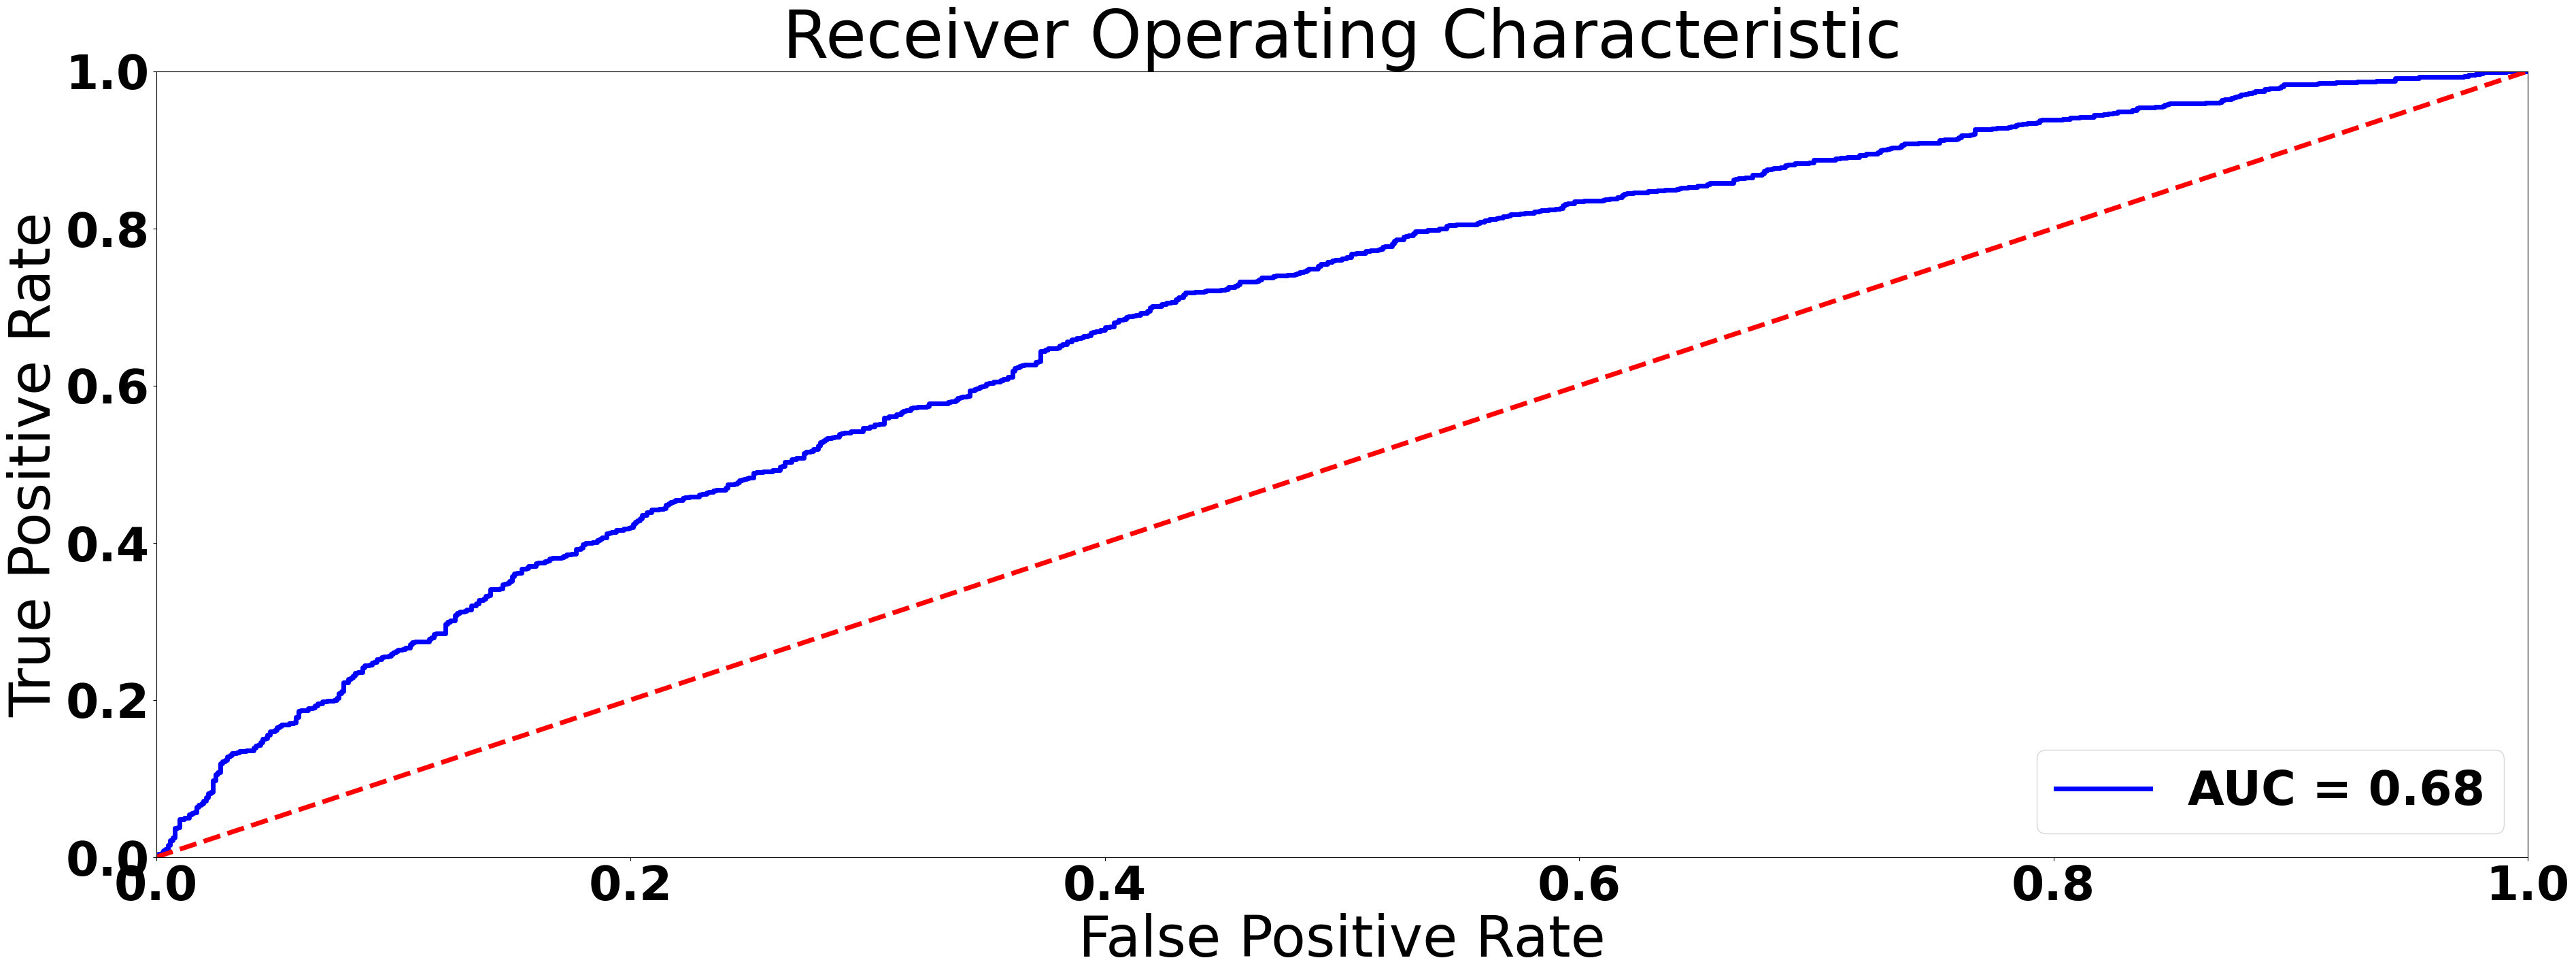

The accuracy score is": 0.641
The f1 score is": 0.666
The recall score is": 0.716
The precision score is": 0.623
The f2 score is": 0.695
The Kappa score is": 0.283
                  precision    recall  f1-score   support

class 0 (Normal)       0.67      0.57      0.61      1000
 class 1 (Fraud)       0.62      0.72      0.67      1000

        accuracy                           0.64      2000
       macro avg       0.64      0.64      0.64      2000
    weighted avg       0.64      0.64      0.64      2000



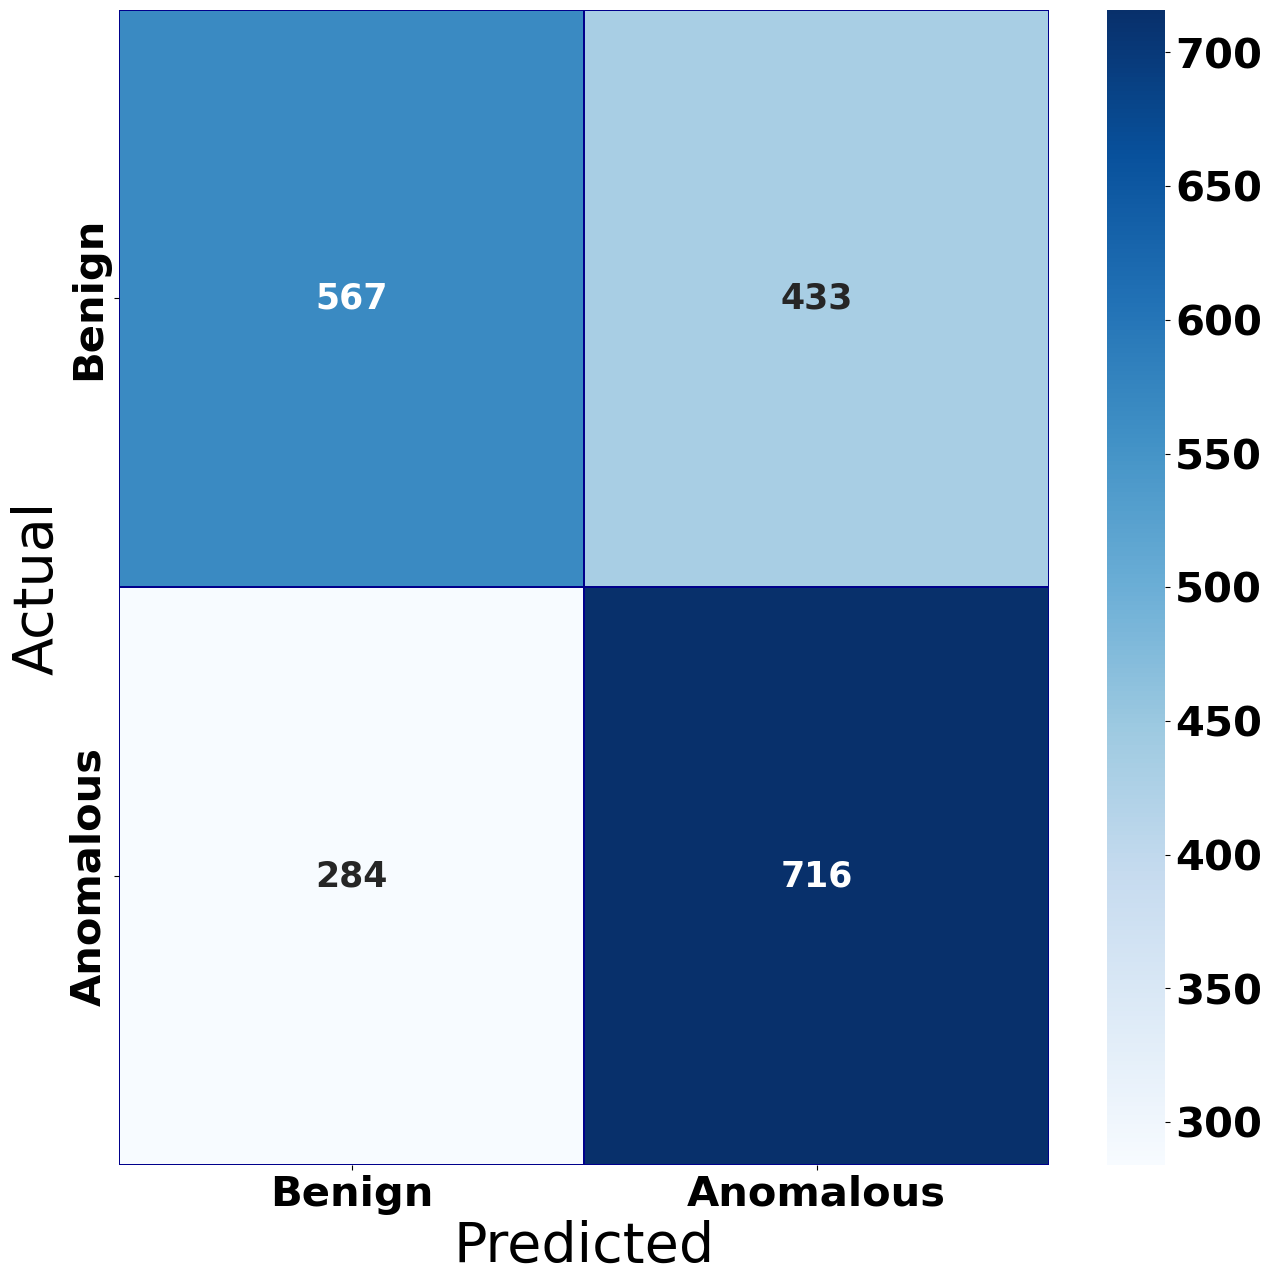

In [38]:
train_amount = 10

test_autoencoder(program_N, program_A, program, SNR, train_amount, check=100)